# Desafío #2 TelecomX — Análisis de Churn
**Objetivo:** Identificar clientes con alta probabilidad de cancelar el servicio, usando EDA, preprocesamiento con Pipeline, modelos de clasificación y optimización con RandomizedSearchCV.

> **Nota metodológica:** `ChargesDaily` y `ChargesTotal` son eliminadas por **multicolinealidad** detectada en la matriz de correlación:  
> - `ChargesDaily` ↔ `ChargesMonthly` → r = 1.00 (misma información, distinta escala)  
> - `ChargesTotal` ↔ `Tenure` → r = 0.83 (derivada del tiempo × precio mensual)  
> Mantener variables redundantes distorsiona los coeficientes del modelo y dificulta la interpretación.

---

## 1. Importación de Librerías

En esta sección se importan todas las dependencias necesarias para el análisis. Se utilizan librerías estándar del ecosistema científico de Python:



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, recall_score, ConfusionMatrixDisplay
)
from scipy.stats import loguniform, randint

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
print('✅ Librerías importadas correctamente.')

✅ Librerías importadas correctamente.


## 2. Carga y Exploración Inicial del Dataset

El dataset `datos_tratados.csv` corresponde a el conjunto de clientes ya filtrado del primer desafío TelecomX. Contiene variables demográficas, de servicios contratados, de facturación y la variable objetivo `Churn` (si el cliente canceló o no el servicio).

En esta primera exploración se revisa:
- Las dimensiones del dataset (filas × columnas).
- Los tipos de datos de cada columna y la presencia de valores nulos.
- Un resumen estadístico de las variables numéricas mediante `describe()`.

Esta etapa es fundamental para entender la estructura de los datos antes de cualquier transformación o modelado.

In [39]:
df = pd.read_csv('datos_tratados.csv')
print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (7043, 22)


,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [40]:
print('=== Tipos de datos ===\n')
print(df.dtypes)
print('\n=== Valores nulos ===\n')
print(df.isnull().sum())

=== Tipos de datos ===

CustomerID           object
Churn                object
Gender               object
SeniorCitizen        object
Partner              object
Dependents           object
Tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
ChargesDaily        float64
ChargesMonthly      float64
ChargesTotal        float64
dtype: object

=== Valores nulos ===

CustomerID          0
Churn               0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV   

In [41]:
df.describe()

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,2.158675,64.761692,2279.734304
std,24.559481,1.003088,30.090047,2266.794470
min,0.000000,0.610000,18.250000,0.000000
25%,9.000000,1.180000,35.500000,398.550000
50%,29.000000,2.340000,70.350000,1394.550000
75%,55.000000,2.990000,89.850000,3786.600000
max,72.000000,3.960000,118.750000,8684.800000


## 3. EDA — Análisis Exploratorio de Datos

El Análisis Exploratorio de Datos (EDA) tiene como objetivo comprender la distribución de las variables, identificar patrones relevantes y detectar posibles problemas en los datos (desbalance de clases, outliers, multicolinealidad).

Este análisis está estructurado en cuatro subsecciones:
1. Distribución de la variable objetivo `Churn`.
2. Distribución de variables numéricas separadas por grupo de Churn.
3. Tasa de Churn por cada variable categórica.
4. Matriz de correlación para detección de multicolinealidad entre variables numéricas.

### 3.1 Distribución de la Variable Objetivo: Churn

El primer paso del EDA es analizar la distribución de la variable objetivo `Churn`. Esto permite identificar si el dataset está **desbalanceado**, situación muy común en problemas de detección de abandono, fraude o fallos.

Un desbalance significativo (por ejemplo, 74% No Churn vs 26% Churn) tiene implicaciones directas en el entrenamiento:
- Los modelos tienden a predecir siempre la clase mayoritaria, obteniendo alta exactitud (accuracy) pero bajo Recall.
- Es necesario usar `class_weight='balanced'` en los modelos y `stratify=y` en el split para compensar este efecto.
- La métrica de evaluación principal debe ser **Recall** o **F1-Score**, no accuracy.

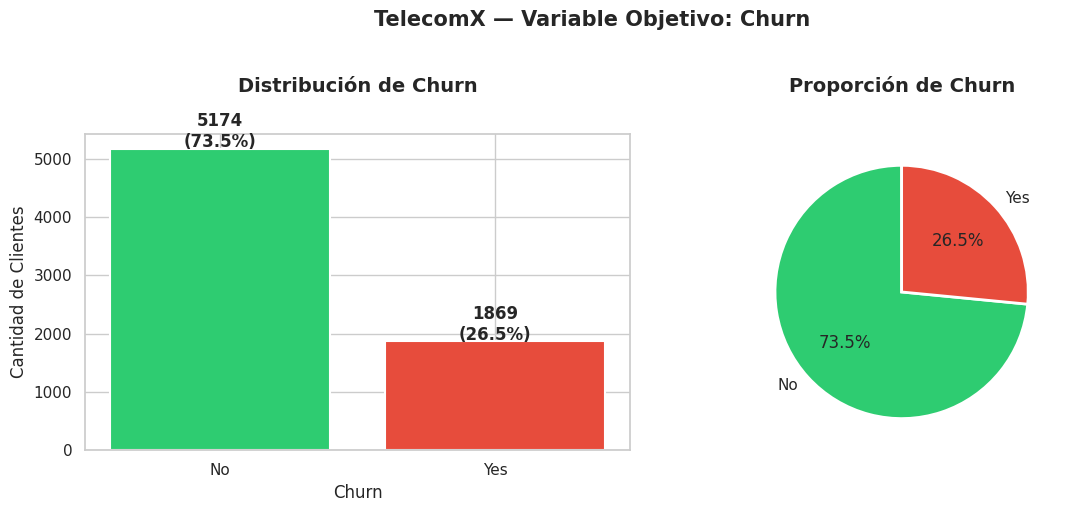


⚠️  Dataset desbalanceado: 26.5% Churn → se usará class_weight="balanced"


In [5]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
for i, (val, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, val + 30, f'{val}\n({pct:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribución de Churn', fontsize=14, fontweight='bold', pad=30)
axes[0].set_ylabel('Cantidad de Clientes')
axes[0].set_xlabel('Churn')

axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Churn', fontsize=14, fontweight='bold', pad=30)

plt.suptitle('TelecomX — Variable Objetivo: Churn', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'\n⚠️  Dataset desbalanceado: {churn_pct["Yes"]:.1f}% Churn → se usará class_weight="balanced"')

### 3.2 Variables Numéricas: Distribuciones por Churn

Se analizan las variables numéricas disponibles en el modelo: `Tenure` (antigüedad del cliente en meses) junto con `ChargesMonthly` (cargo mensual en dólares), `ChargesDaily` y `ChargesTotal` .

Se utilizan dos tipos de gráficos complementarios:
- **Histogramas superpuestos**: permiten observar la forma de la distribución para cada grupo (`Churn=Yes` vs `Churn=No`) e identificar si existe separación entre ellas.
- **Boxplots**: muestran la mediana, el rango intercuartílico y los valores atípicos por grupo, facilitando la comparación de tendencia central y dispersión.



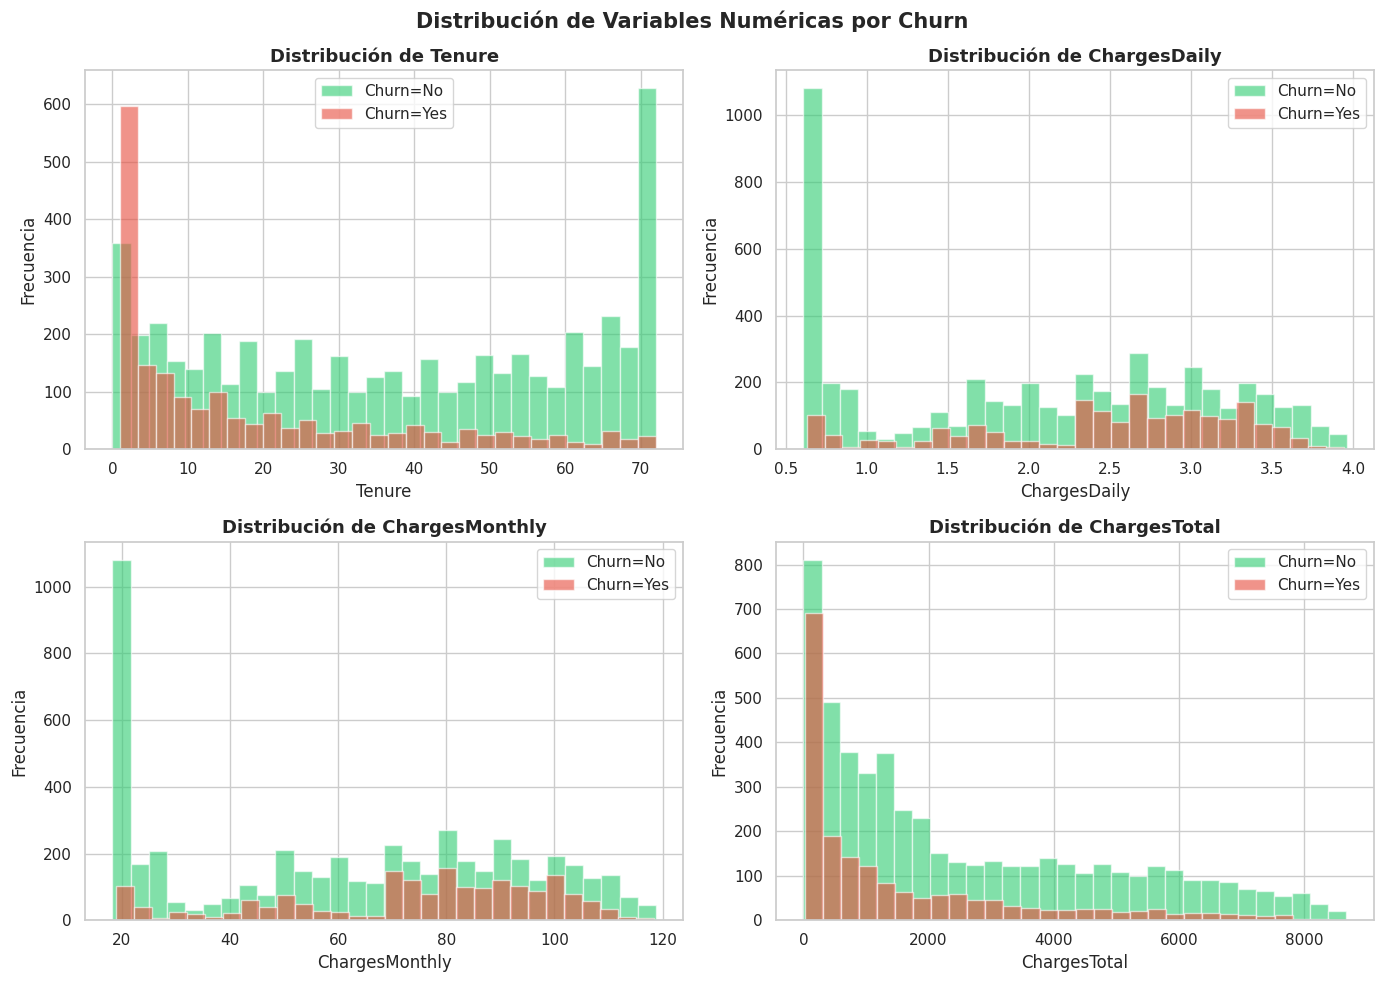

In [45]:
num_cols = ['Tenure', 'ChargesDaily', 'ChargesMonthly', 'ChargesTotal']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
        axes[i].hist(df[df['Churn'] == label][col], bins=30, alpha=0.6,
                     label=f'Churn={label}', color=color, edgecolor='white')
    axes[i].set_title(f'Distribución de {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

plt.suptitle('Distribución de Variables Numéricas por Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

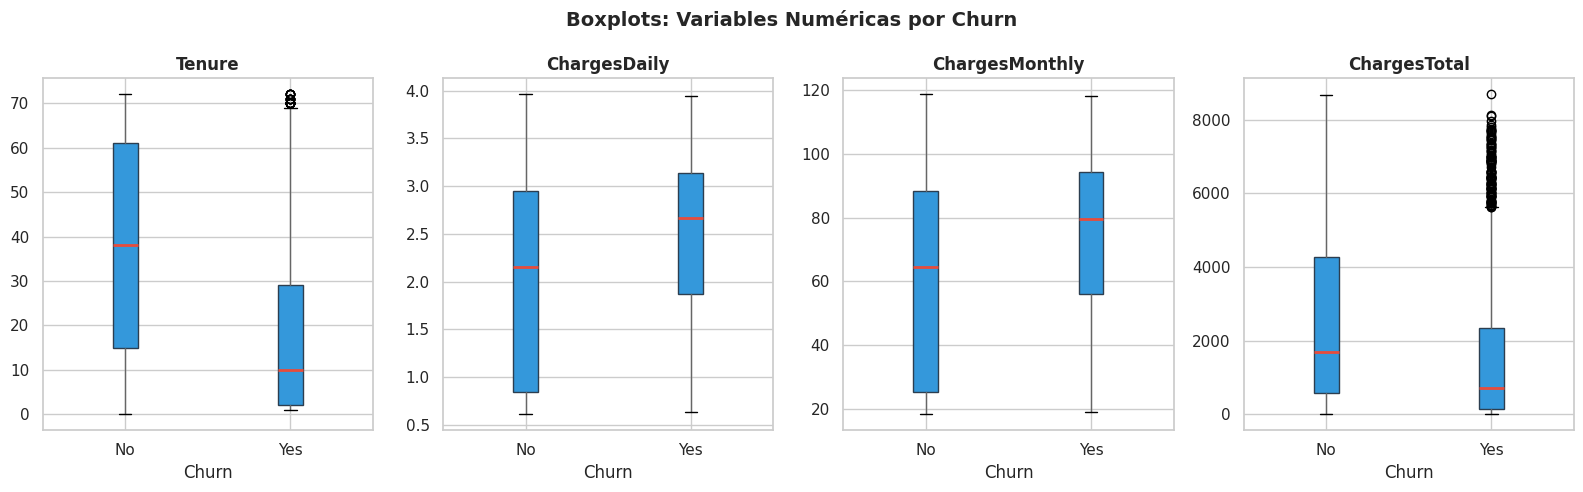

In [46]:
# Boxplots
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='Churn', ax=axes[i], patch_artist=True,
               boxprops=dict(facecolor='#3498db', color='#2c3e50'),
               medianprops=dict(color='#e74c3c', linewidth=2))
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Churn')

plt.suptitle('Boxplots: Variables Numéricas por Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Variables Categóricas: Tasa de Churn

Para las variables categóricas se calcula la **tasa de Churn por categoría**: el porcentaje de clientes que abandonaron el servicio dentro de cada grupo. Este indicador permite identificar qué valores de cada variable están más asociados con la cancelación.

Las variables analizadas cubren aspectos demográficos (`Gender`, `SeniorCitizen`, `Partner`, `Dependents`), de servicios contratados (`PhoneService`, `InternetService`, servicios adicionales) y de contrato y facturación (`Contract`, `PaperlessBilling`, `PaymentMethod`).

La escala de color utilizada (verde → rojo) permite identificar visualmente las categorías de mayor riesgo.

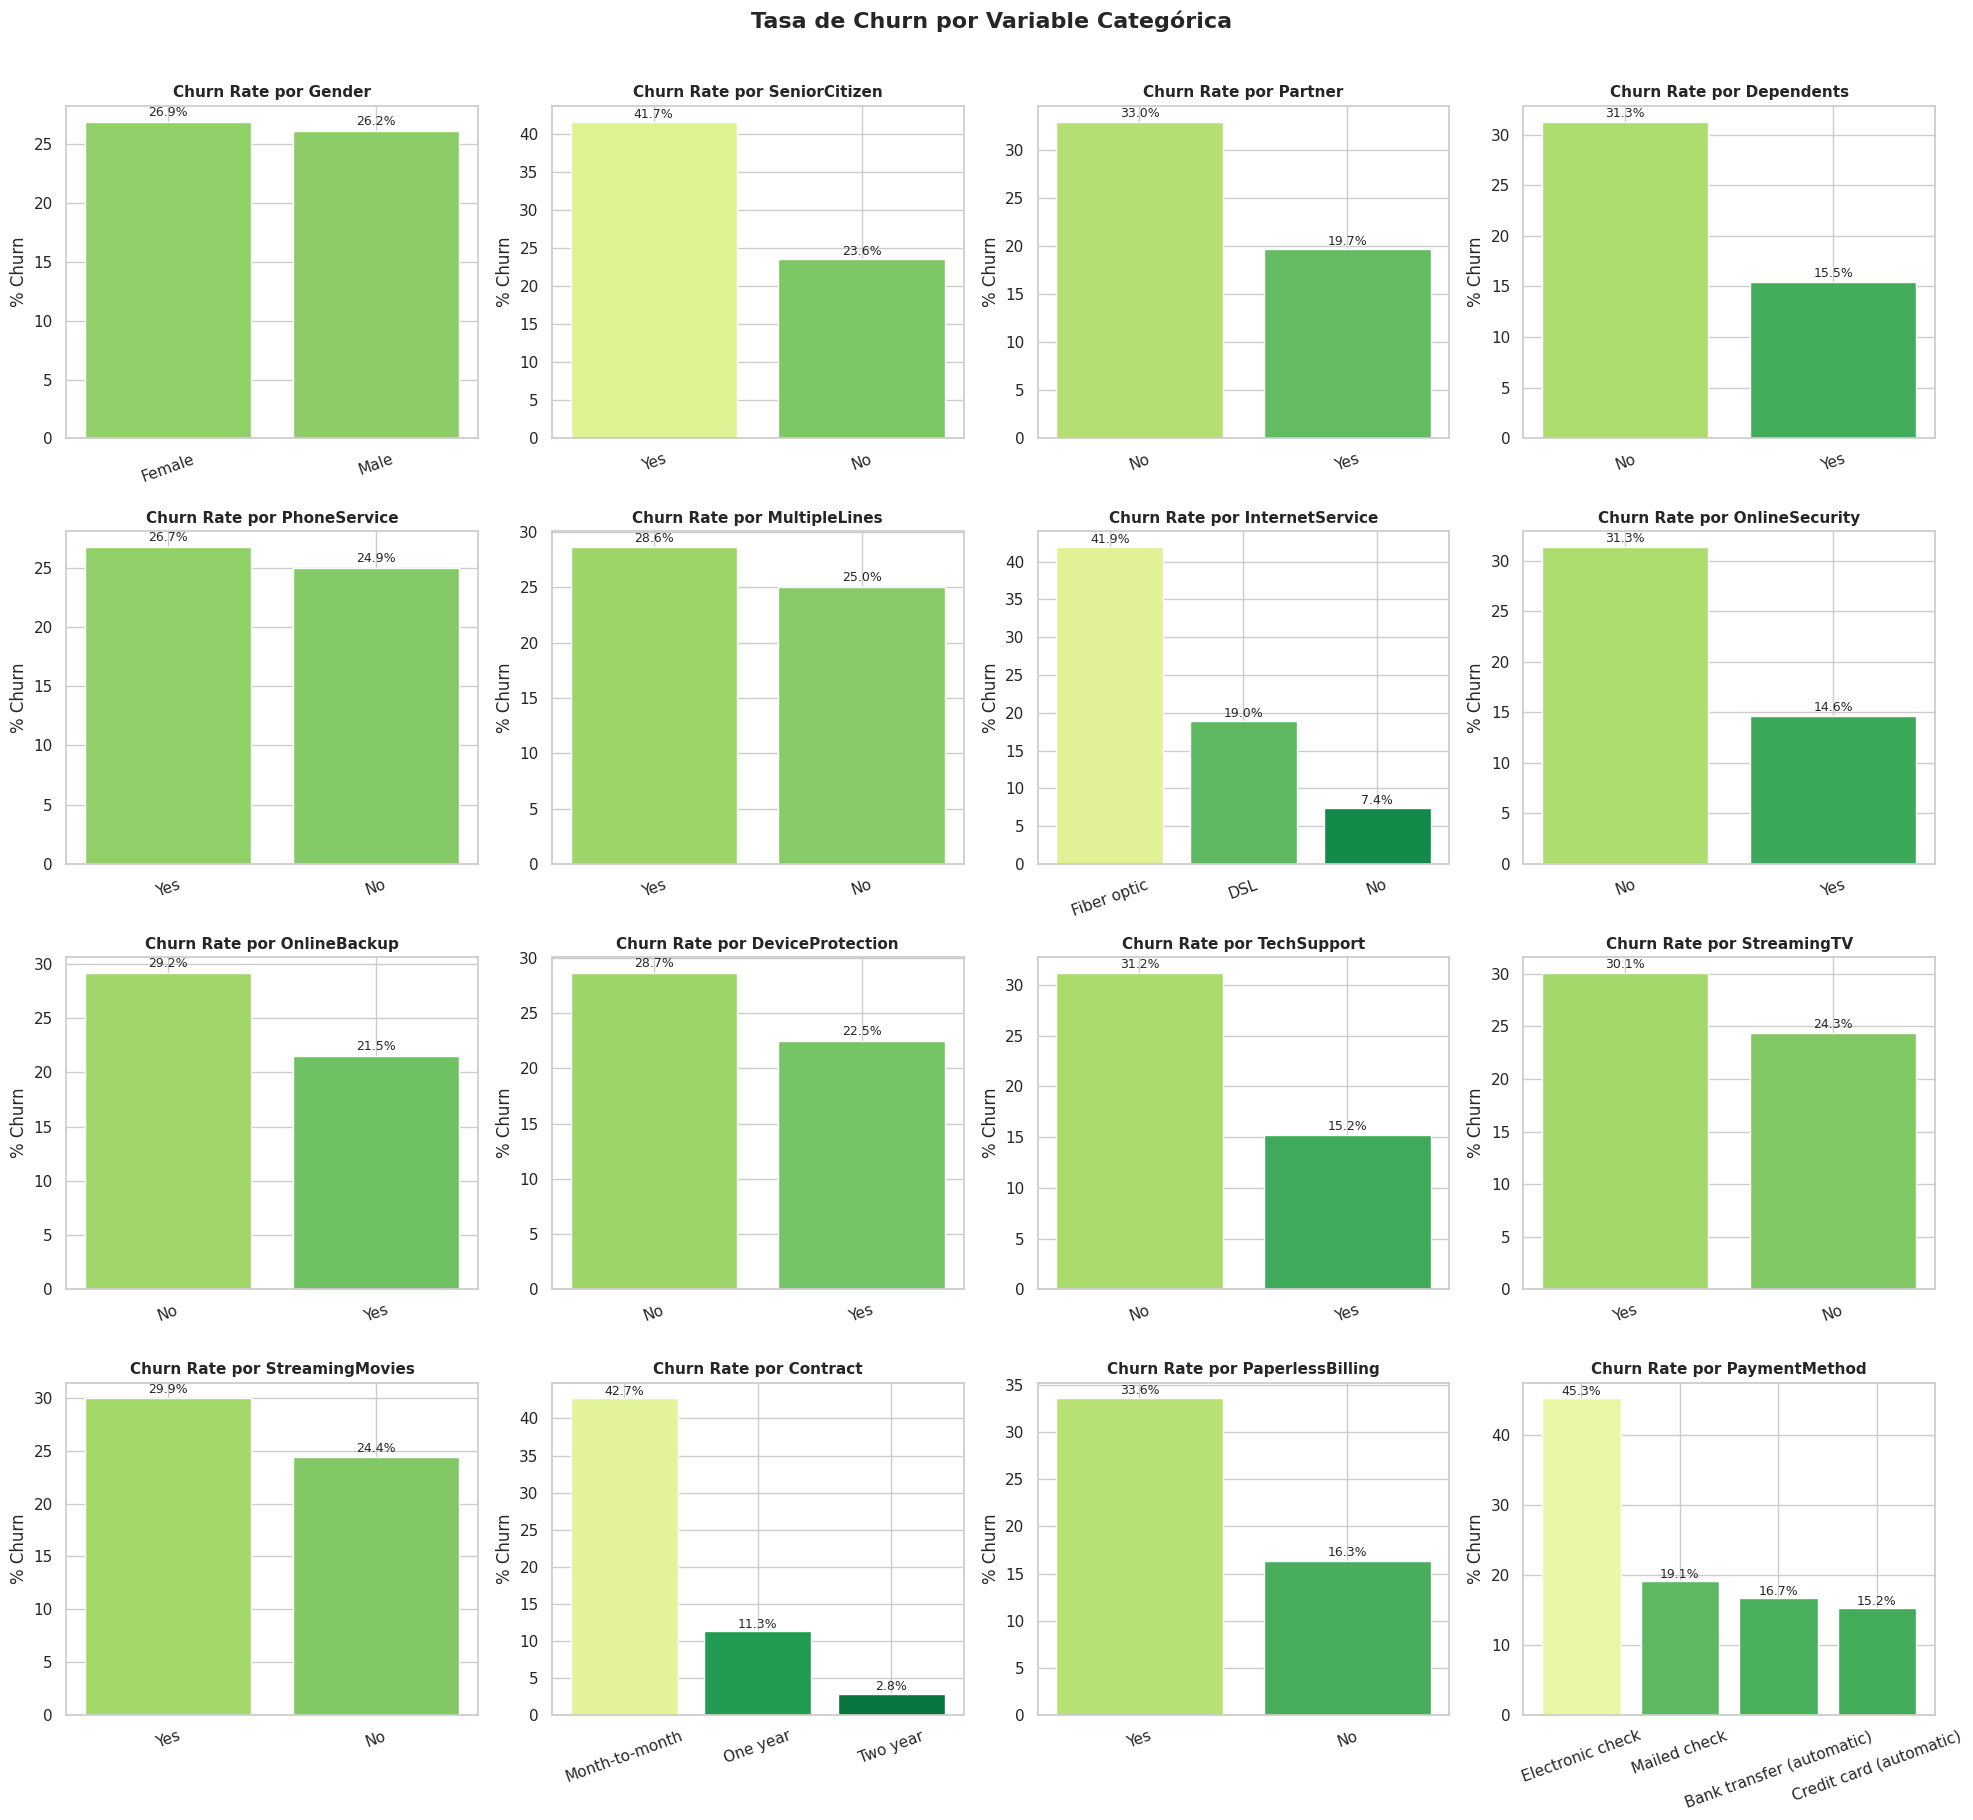

In [8]:
cat_cols = ['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    churn_rate.columns = [col, 'ChurnRate']
    churn_rate = churn_rate.sort_values('ChurnRate', ascending=False)

    bars = axes[i].bar(churn_rate[col], churn_rate['ChurnRate'],
                       color=plt.cm.RdYlGn_r(churn_rate['ChurnRate'] / 100),
                       edgecolor='white')
    axes[i].set_title(f'Churn Rate por {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('% Churn')
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, churn_rate['ChurnRate']):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Tasa de Churn por Variable Categórica', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Matriz de Correlación y Detección de Multicolinealidad

> Este análisis es la **justificación técnica** para eliminar `ChargesDaily` y `ChargesTotal`.  
> Variables con correlación muy alta aportan información redundante y pueden distorsionar los coeficientes del modelo.

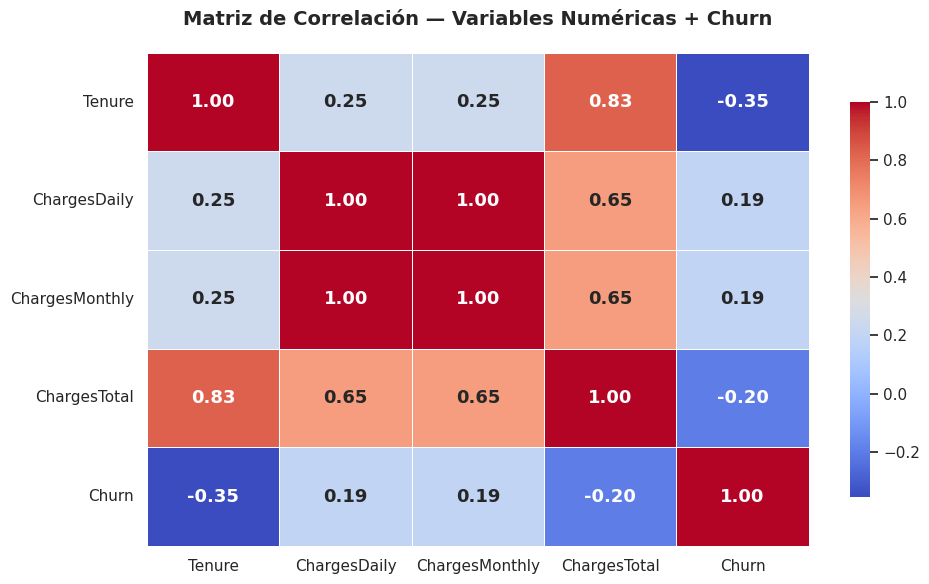

In [52]:
# Correlación con TODAS las variables numéricas originales
df_numeric = df[['Tenure', 'ChargesDaily', 'ChargesMonthly', 'ChargesTotal']].copy()
df_numeric['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

corr_matrix = df_numeric.corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 13, 'weight': 'bold'})
plt.title('Matriz de Correlación — Variables Numéricas + Churn', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Interpretación
r_daily_monthly = corr_matrix.loc['ChargesDaily', 'ChargesMonthly']
r_total_tenure  = corr_matrix.loc['ChargesTotal', 'Tenure']
r_daily_churn   = corr_matrix.loc['ChargesDaily', 'Churn']
r_total_churn   = corr_matrix.loc['ChargesTotal', 'Churn']

In [49]:
print(f"""
════════════════════════════════════════════════════════════════════
         ANÁLISIS DE MULTICOLINEALIDAD — DECISIÓN DE FEATURES
════════════════════════════════════════════════════════════════════

  ChargesDaily  ↔ ChargesMonthly : r = {r_daily_monthly:.2f}  ← correlación PERFECTA
  ChargesTotal  ↔ Tenure         : r = {r_total_tenure:.2f}  ← correlación MUY ALTA

  ¿Por qué ocurre esto?
  • ChargesDaily = ChargesMonthly / 30  → misma información, distinta escala
  • ChargesTotal ≈ ChargesMonthly × Tenure → es una combinación de las otras dos

  ¿Qué problema genera en el modelo?
  • En Regresión Logística: infla varianza de coeficientes, hace difícil
    interpretar qué variable tiene el efecto real.
  • En Random Forest: variables redundantes 'roban' importancia entre sí,
    subestimando el impacto de cada una.

  ✅ DECISIÓN: eliminar ChargesDaily y ChargesTotal
     Se conserva → ChargesMonthly : precio actual del cliente
     Se conserva → Tenure          : tiempo como cliente
     Ambas son suficientes para capturar el patrón de facturación.
""")


════════════════════════════════════════════════════════════════════
         ANÁLISIS DE MULTICOLINEALIDAD — DECISIÓN DE FEATURES     
════════════════════════════════════════════════════════════════════

  ChargesDaily  ↔ ChargesMonthly : r = 1.00  ← correlación PERFECTA
  ChargesTotal  ↔ Tenure         : r = 0.83  ← correlación MUY ALTA

  ¿Por qué ocurre esto?
  • ChargesDaily = ChargesMonthly / 30  → misma información, distinta escala
  • ChargesTotal ≈ ChargesMonthly × Tenure → es una combinación de las otras dos

  ¿Qué problema genera en el modelo?
  • En Regresión Logística: infla varianza de coeficientes, hace difícil
    interpretar qué variable tiene el efecto real.
  • En Random Forest: variables redundantes 'roban' importancia entre sí,
    subestimando el impacto de cada una.

  ✅ DECISIÓN: eliminar ChargesDaily y ChargesTotal
     Se conserva → ChargesMonthly : precio actual del cliente
     Se conserva → Tenure          : tiempo como cliente
     Ambas son suficientes

## 4. Preprocesamiento

El preprocesamiento transforma el dataset crudo en una representación adecuada para los algoritmos de Machine Learning. Las transformaciones aplicadas son:

1. **Eliminación de columnas irrelevantes o redundantes**: se elimina `CustomerID` (identificador sin valor predictivo) y las variables `ChargesDaily` y `ChargesTotal` (redundantes por multicolinealidad, ver sección 3.4).
2. **Codificación de la variable objetivo**: `Churn` se convierte a variable binaria (1 = canceló, 0 = no canceló).
3. **Separación de features**: se distinguen automáticamente las variables numéricas (escalables) de las categóricas (codificables).

El preprocesamiento se implementa dentro de un `Pipeline` de scikit-learn, lo que garantiza que las transformaciones se aplican de forma consistente tanto al conjunto de entrenamiento como al de prueba, evitando *data leakage*.

In [10]:
df_model = df.drop(columns=['CustomerID'])
df_model = df_model.drop(columns=['ChargesDaily', 'ChargesTotal'])  # multicolinealidad → ver sección 3.4
X = df_model.drop(columns=['Churn'])
y = (df_model['Churn'] == 'Yes').astype(int)   # 1 = Churn, 0 = No Churn

print(f'Features : {X.shape[1]} columnas | {X.shape[0]} filas')
print(f'No Churn : {(y==0).sum()} | Churn: {(y==1).sum()}')

Features : 18 columnas | 7043 filas
No Churn : 5174 | Churn: 1869


In [11]:
numerical_features   = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numéricas  : {numerical_features}')
print(f'Categóricas: {categorical_features}')

Numéricas  : ['Tenure', 'ChargesMonthly']
Categóricas: ['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 4.1 Split Estratificado (Stratify)

El dataset se divide en conjunto de entrenamiento (80%) y conjunto de prueba (20%). Se utiliza el parámetro `stratify=y` para garantizar que la proporción de clientes con Churn se mantiene igual en ambos subconjuntos.

Esta estratificación es especialmente importante en datasets desbalanceados (como este, con ~26% de Churn), ya que un split aleatorio podría generar un conjunto de prueba con una distribución diferente a la del entrenamiento, produciendo estimaciones de rendimiento poco confiables.

Se fija `random_state=42` para reproducibilidad de los resultados.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} muestras | Churn rate: {y_train.mean()*100:.1f}%')
print(f'Test  : {X_test.shape[0]} muestras  | Churn rate: {y_test.mean()*100:.1f}%')

Train : 5634 muestras | Churn rate: 26.5%
Test  : 1409 muestras  | Churn rate: 26.5%


### 4.2 Preprocesador con ColumnTransformer

Se construye un `ColumnTransformer` que aplica transformaciones distintas según el tipo de variable:

- **`StandardScaler`** sobre variables numéricas (`Tenure`, `ChargesMonthly`): estandariza los valores a media 0 y desviación estándar 1. Esto es necesario para la Regresión Logística, cuyos coeficientes son sensibles a la escala de las variables.
- **`OneHotEncoder`** sobre variables categóricas: convierte cada categoría en una columna binaria independiente. Se usa `handle_unknown='ignore'` para gestionar categorías no vistas durante el entrenamiento.

Este preprocesador se integra como primer paso en cada Pipeline de modelo, asegurando que no hay fuga de información del conjunto de prueba al de entrenamiento.

In [13]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

print('✅ Preprocesador configurado:')
print('   StandardScaler  → variables numéricas')
print('   OneHotEncoder   → variables categóricas')

✅ Preprocesador configurado:
   StandardScaler  → variables numéricas
   OneHotEncoder   → variables categóricas


## 5. Modelos Base — Pipelines

Antes de optimizar hiperparámetros, se entrena cada modelo con su configuración por defecto (o una configuración razonable). Estos **modelos base** sirven como línea de referencia (*baseline*) para medir el impacto de la optimización posterior.

Se utilizan dos algoritmos de clasificación:

- **Regresión Logística**: modelo lineal interpretable, adecuado cuando las relaciones entre variables y Churn son aproximadamente lineales. Se usa `class_weight='balanced'` para compensar el desbalance de clases.
- **Random Forest**: ensemble de árboles de decisión, capaz de capturar interacciones no lineales y relaciones complejas entre variables. También con `class_weight='balanced'`.

Cada modelo se encapsula en un `Pipeline` que incluye el preprocesador de la sección anterior, garantizando que las transformaciones y el modelo se apliquen siempre de forma conjunta.

In [53]:
#  Regresión Logística base
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

#  Random Forest base
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200, max_depth=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
print('✅ Modelos base entrenados.')

✅ Modelos base entrenados.


## 6. Evaluación — Modelos Base

Se evalúa el rendimiento de los modelos base sobre el conjunto de prueba. Para problemas de Churn, la selección de métricas es crítica:

- **Recall (Sensibilidad)**: fracción de clientes que realmente hicieron Churn y el modelo identificó correctamente. Es la **métrica principal** en este problema, ya que un falso negativo (cliente que se va y no detectamos) tiene un coste de negocio mucho mayor que un falso positivo.
- **ROC-AUC**: mide la capacidad discriminativa del modelo en todos los umbrales de decisión. Un valor de 1.0 es perfecto; 0.5 equivale a un clasificador aleatorio.
- **F1-Score**: media armónica entre precisión y recall, útil como métrica de balance general.

Adicionalmente se muestra el `classification_report` completo con precisión, recall y F1 por clase.

In [54]:
def evaluar_modelo(nombre, pipeline, X_test, y_test):
    """Evalúa un pipeline y retorna dict con métricas y predicciones."""
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    roc = roc_auc_score(y_test, y_prob)
    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    print(f'\n{"="*55}')
    print(f' {nombre}')
    print(f'{"="*55}')
    print(f'  ROC-AUC : {roc:.4f}')
    print(f'  Recall  : {rec:.4f}   ← métrica principal para Churn')
    print(f'  F1-Score: {f1:.4f}')
    print(f'\n{classification_report(y_test, y_pred, target_names=["No Churn", "Churn"])}')

    return {'nombre': nombre, 'roc_auc': roc, 'recall': rec, 'f1': f1,
            'y_pred': y_pred, 'y_prob': y_prob}

res_lr = evaluar_modelo('LR  Base', pipe_lr, X_test, y_test)
res_rf = evaluar_modelo('RF  Base', pipe_rf, X_test, y_test)


 LR  Base
  ROC-AUC : 0.8422
  Recall  : 0.7834   ← métrica principal para Churn
  F1-Score: 0.6168

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409


 RF  Base
  ROC-AUC : 0.8416
  Recall  : 0.7193   ← métrica principal para Churn
  F1-Score: 0.6270

              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1035
       Churn       0.56      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



## 7. Optimización — RandomizedSearchCV

La optimización de hiperparámetros busca la configuración que maximiza el rendimiento del modelo en validación cruzada. Se utiliza `RandomizedSearchCV` en lugar de `GridSearchCV` por su eficiencia: en lugar de explorar todas las combinaciones posibles, muestrea aleatoriamente del espacio de búsqueda definido.

**Configuración del proceso:**
- `scoring='recall'`: se optimiza directamente la métrica más relevante para Churn (detectar el mayor número de clientes en riesgo).
- `cv=StratifiedKFold(n_splits=5)`: validación cruzada estratificada en 5 folds, manteniendo la proporción de clases en cada partición.
- `n_iter=40`: se evalúan 40 combinaciones aleatorias de hiperparámetros por modelo.
- `refit=True`: el mejor estimador se re-entrena automáticamente con todos los datos de entrenamiento.

Los parámetros dentro del Pipeline se referencian con el prefijo `classifier__` seguido del nombre del parámetro del estimador.

### 7.1 Regresión Logística — RandomizedSearch

El espacio de búsqueda cubre los hiperparámetros más relevantes de la Regresión Logística:
- **`C`** (inverso de la regularización): valores en distribución log-uniforme entre 0.001 y 100. Valores bajos aumentan la regularización (modelo más simple); valores altos la reducen (modelo más flexible).
- **`penalty`**: tipo de regularización (`l1` genera soluciones dispersas; `l2` distribuye el peso entre todas las variables).
- **`solver`**: algoritmo de optimización, restringido a `liblinear` y `saga` por compatibilidad con ambos tipos de penalización.
- **`class_weight`**: controla si se pondera la clase minoritaria para compensar el desbalance.

In [16]:
# Los parámetros van prefijados con 'classifier__' por el Pipeline
param_dist_lr = {
    'classifier__C'           : loguniform(0.001, 100),   # Regularización inversa
    'classifier__penalty'     : ['l1', 'l2'],              # Tipo de regularización
    'classifier__solver'      : ['liblinear', 'saga'],     # Compatibles con l1 y l2
    'classifier__class_weight': ['balanced', None],
    'classifier__max_iter'    : [500, 1000, 2000]
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs_lr = RandomizedSearchCV(
    estimator            = pipe_lr,
    param_distributions  = param_dist_lr,
    n_iter               = 40,
    scoring              = 'recall',   # ← optimizamos Recall
    cv                   = cv_strat,
    n_jobs               = -1,
    random_state         = 42,
    verbose              = 1,
    refit                = True        # refit con mejores params sobre X_train completo
)

rs_lr.fit(X_train, y_train)

print(f'\n🏅 Mejores hiperparámetros — Regresión Logística:')
for k, v in rs_lr.best_params_.items():
    print(f'   {k}: {v}')
print(f'\n   Recall CV (best): {rs_lr.best_score_:.4f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

🏅 Mejores hiperparámetros — Regresión Logística:
   classifier__C: 0.0035502556123130774
   classifier__class_weight: balanced
   classifier__max_iter: 2000
   classifier__penalty: l2
   classifier__solver: liblinear

   Recall CV (best): 0.7980


### 7.2 Random Forest — RandomizedSearch

El espacio de búsqueda del Random Forest cubre los hiperparámetros que controlan la complejidad del ensemble y de cada árbol individual:
- **`n_estimators`**: número de árboles en el bosque (100 a 600). Más árboles reducen la varianza pero aumentan el tiempo de cómputo.
- **`max_depth`**: profundidad máxima de cada árbol. Limitar la profundidad evita el sobreajuste.
- **`min_samples_split` y `min_samples_leaf`**: controlan cuántos ejemplos mínimos son necesarios para dividir un nodo o formar una hoja, regulando la granularidad del árbol.
- **`max_features`**: número de variables consideradas en cada división (`sqrt`, `log2` o el 50% del total). Introduce diversidad entre árboles.

In [55]:
param_dist_rf = {
    'classifier__n_estimators'     : randint(100, 600),
    'classifier__max_depth'        : [None, 5, 10, 15, 20, 30],
    'classifier__min_samples_split': randint(2, 20),
    'classifier__min_samples_leaf' : randint(1, 10),
    'classifier__max_features'     : ['sqrt', 'log2', 0.5],
    'classifier__class_weight'     : ['balanced', 'balanced_subsample']
}

rs_rf = RandomizedSearchCV(
    estimator            = pipe_rf,
    param_distributions  = param_dist_rf,
    n_iter               = 40,
    scoring              = 'recall',
    cv                   = cv_strat,
    n_jobs               = -1,
    random_state         = 42,
    verbose              = 1,
    refit                = True
)

rs_rf.fit(X_train, y_train)

print(f'\n Mejores hiperparámetros — Random Forest:')
for k, v in rs_rf.best_params_.items():
    print(f'   {k}: {v}')
print(f'\n   Recall CV (best): {rs_rf.best_score_:.4f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

 Mejores hiperparámetros — Random Forest:
   classifier__class_weight: balanced
   classifier__max_depth: 5
   classifier__max_features: sqrt
   classifier__min_samples_leaf: 2
   classifier__min_samples_split: 10
   classifier__n_estimators: 445

   Recall CV (best): 0.8107


### 7.3 Evaluación de Modelos Optimizados

Se evalúan los mejores estimadores encontrados por `RandomizedSearchCV` sobre el conjunto de prueba. Esta evaluación utiliza la misma función `evaluar_modelo()` definida en la sección 6, garantizando comparabilidad directa con los modelos base.

In [18]:
res_lr_opt = evaluar_modelo('LR  Optimizado', rs_lr.best_estimator_, X_test, y_test)
res_rf_opt = evaluar_modelo('RF  Optimizado', rs_rf.best_estimator_, X_test, y_test)


📊 LR  Optimizado
  ROC-AUC : 0.8400
  Recall  : 0.7968   ← métrica principal para Churn
  F1-Score: 0.6307

              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409


📊 RF  Optimizado
  ROC-AUC : 0.8418
  Recall  : 0.8102   ← métrica principal para Churn
  F1-Score: 0.6228

              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.51      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## 8. Comparación Completa: Base vs Optimizado

Esta sección consolida los resultados de los cuatro modelos entrenados (LR Base, RF Base, LR Optimizado, RF Optimizado) y los compara mediante distintas herramientas de evaluación:

- **Tabla de métricas**: visión numérica directa de Recall, ROC-AUC y F1-Score.
- **Gráfico de barras comparativo**: facilita la comparación visual entre versiones base y optimizada.
- **Matrices de confusión**: muestran la distribución concreta de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.
- **Curvas ROC**: permiten evaluar el trade-off entre sensibilidad y especificidad en todos los umbrales posibles.
- **Análisis cualitativo**: interpretación de por qué un algoritmo puede superar al otro en este dataset específico.

### 8.1 Tabla de Métricas

Se construye una tabla comparativa con los tres indicadores clave (Recall ⭐, ROC-AUC, F1-Score) para los cuatro modelos. Esta tabla permite identificar de forma directa qué configuración ofrece el mejor balance y cuál es el modelo ganador según cada criterio.

In [19]:
todos = [res_lr, res_rf, res_lr_opt, res_rf_opt]

tabla = pd.DataFrame([
    {'Modelo': r['nombre'], 'ROC-AUC': r['roc_auc'], 'Recall': r['recall'], 'F1-Score': r['f1']}
    for r in todos
]).set_index('Modelo')

print('\n📊 Comparación de Métricas — Todos los Modelos (⭐ = métrica principal):')
print(tabla.round(4).to_string())
print()
print(f'⭐ Mejor Recall  : {tabla["Recall"].idxmax():<30} ({tabla["Recall"].max():.4f})')
print(f'   Mejor ROC-AUC : {tabla["ROC-AUC"].idxmax():<30} ({tabla["ROC-AUC"].max():.4f})')
print(f'   Mejor F1-Score: {tabla["F1-Score"].idxmax():<30} ({tabla["F1-Score"].max():.4f})')


📊 Comparación de Métricas — Todos los Modelos (⭐ = métrica principal):
                ROC-AUC  Recall  F1-Score
Modelo                                   
LR  Base         0.8422  0.7834    0.6168
RF  Base         0.8416  0.7193    0.6270
LR  Optimizado   0.8400  0.7968    0.6307
RF  Optimizado   0.8418  0.8102    0.6228

⭐ Mejor Recall  : RF  Optimizado                 (0.8102)
   Mejor ROC-AUC : LR  Base                       (0.8422)
   Mejor F1-Score: LR  Optimizado                 (0.6307)


### 8.2 Gráfico Comparativo — Base vs Optimizado

La representación visual facilita comparar el impacto de la optimización sobre cada métrica. Las barras más oscuras corresponden a los modelos optimizados; las más claras a los modelos base. Una mejora notable indica que el espacio de búsqueda de hiperparámetros era relevante para el modelo en cuestión.

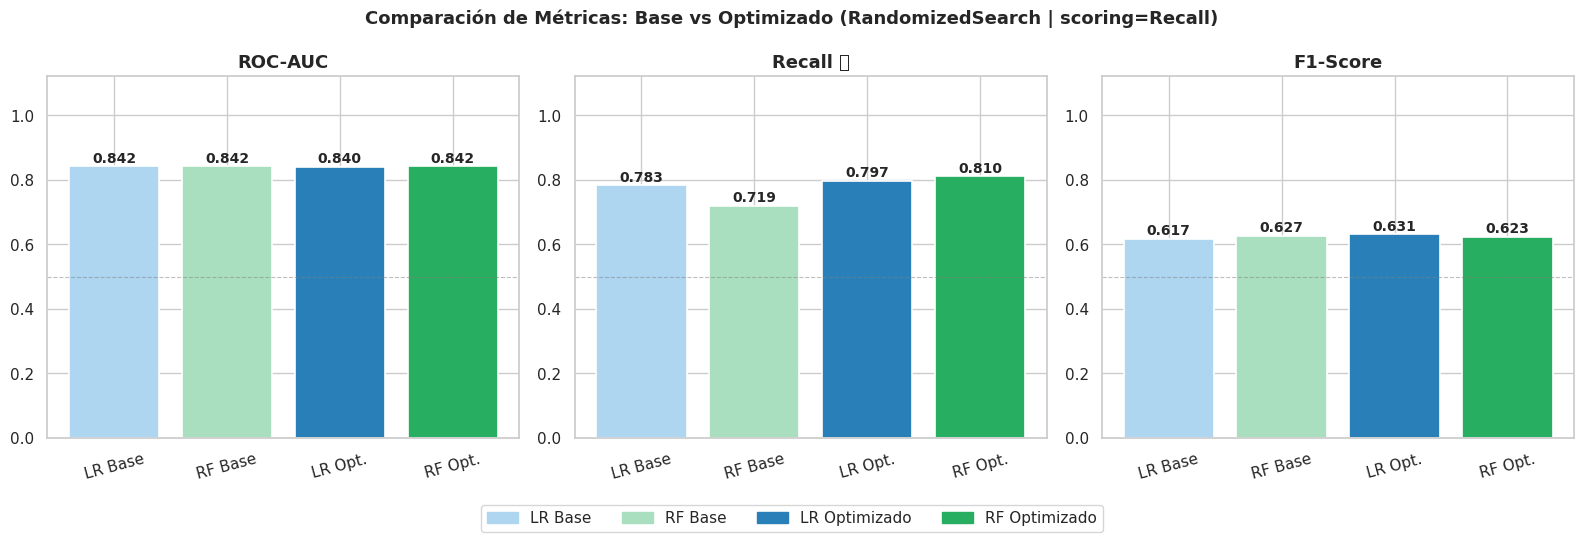

In [20]:
metricas_cols  = ['ROC-AUC', 'Recall', 'F1-Score']
modelos_labels = ['LR Base', 'RF Base', 'LR Opt.', 'RF Opt.']
colores        = ['#aed6f1', '#a9dfbf', '#2980b9', '#27ae60']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metrica in zip(axes, metricas_cols):
    vals = tabla[metrica].values
    bars = ax.bar(modelos_labels, vals, color=colores, edgecolor='white', linewidth=1.2)
    ax.set_ylim(0, 1.12)
    titulo = f'{metrica} ⭐' if metrica == 'Recall' else metrica
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

legend_patches = [
    mpatches.Patch(color='#aed6f1', label='LR Base'),
    mpatches.Patch(color='#a9dfbf', label='RF Base'),
    mpatches.Patch(color='#2980b9', label='LR Optimizado'),
    mpatches.Patch(color='#27ae60', label='RF Optimizado')
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=11, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Comparación de Métricas: Base vs Optimizado (RandomizedSearch | scoring=Recall)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.3 Matrices de Confusión — Los 4 Modelos

La matriz de confusión descompone las predicciones en cuatro categorías:
- **Verdadero Negativo (TN)**: cliente no hace Churn y el modelo predice No Churn.
- **Falso Positivo (FP)**: cliente no hace Churn pero el modelo predice Churn (alarma falsa).
- **Falso Negativo (FN)**: cliente hace Churn pero el modelo predice No Churn (**el error más costoso para el negocio**).
- **Verdadero Positivo (TP)**: cliente hace Churn y el modelo lo detecta correctamente.

Minimizar los FN es el objetivo principal de la optimización por Recall.

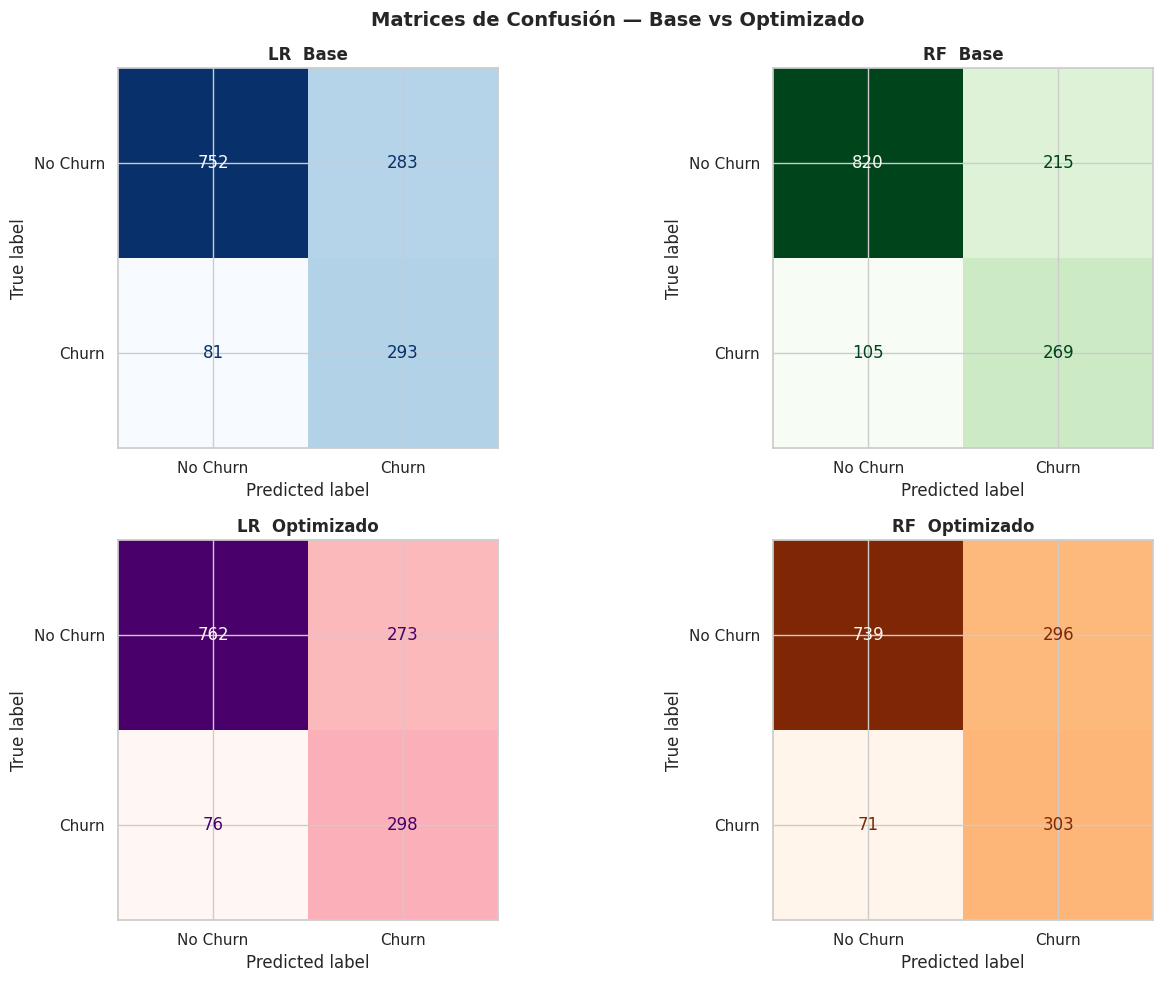

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
cmaps = ['Blues', 'Greens', 'RdPu', 'Oranges']

for ax, res, cmap in zip(axes, todos, cmaps):
    cm   = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(res['nombre'], fontsize=12, fontweight='bold')

plt.suptitle('Matrices de Confusión — Base vs Optimizado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.4 Curvas ROC — Los 4 Modelos

La curva ROC (Receiver Operating Characteristic) representa el trade-off entre la Tasa de Verdaderos Positivos (Recall/TPR) y la Tasa de Falsos Positivos (FPR) para todos los umbrales de decisión posibles. El área bajo la curva (AUC) resume este trade-off en un único valor: cuanto más cercano a 1.0, mejor es la capacidad discriminativa del modelo, independientemente del umbral elegido.

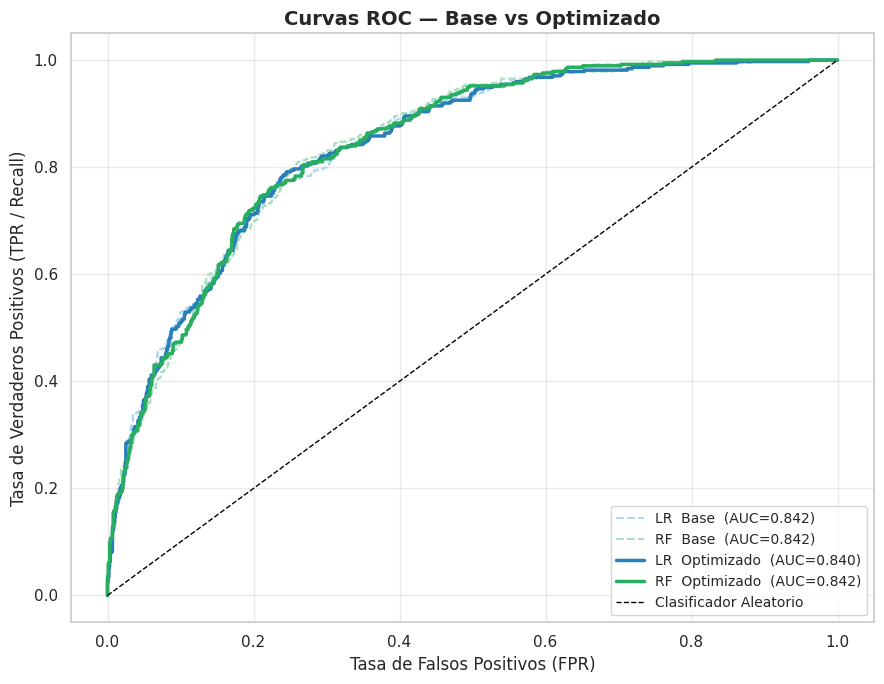

In [22]:
estilos  = ['--', '--', '-',  '-' ]
colores4 = ['#aed6f1', '#a9dfbf', '#2980b9', '#27ae60']
widths   = [1.5, 1.5, 2.5, 2.5]

plt.figure(figsize=(9, 7))

for res, color, ls, lw in zip(todos, colores4, estilos, widths):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr,
             label=f"{res['nombre']}  (AUC={res['roc_auc']:.3f})",
             color=color, linestyle=ls, linewidth=lw)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)
plt.title('Curvas ROC — Base vs Optimizado', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 8.5 Análisis: ¿Por qué Regresión Logística es preferida para Churn?

No existe un algoritmo universalmente superior. La elección depende de la naturaleza del problema y la estructura de los datos. En este caso se analiza por qué la Regresión Logística puede igualar o superar al Random Forest, a pesar de ser un modelo más simple.

In [56]:
delta_lr = res_lr_opt['recall'] - res_lr['recall']
delta_rf = res_rf_opt['recall'] - res_rf['recall']

print(f"""

          ¿POR QUÉ REGRESIÓN LOGÍSTICA ES PREFERIDA PARA CHURN?
══════════════════════════════════════════════════════════════════════════

No es una regla universal — depende de la naturaleza del dataset.
En TelecomX, la LR gana porque las relaciones son LINEALES:

  • Más Tenure          → menos Churn     (lineal negativa clara)
  • Más Charges         → más Churn       (lineal positiva)
  • Contrato mensual    → más Churn       (efecto directo y aditivo)
  • Sin seguridad online → más Churn      (efecto directo)

Random Forest necesita interacciones complejas (no lineales) para
superar a LR. Cuando el problema es esencialmente lineal, RF sufre
de alta varianza con pocas ganancias en bias.

  Ganancia de RandomizedSearch sobre Recall:
  LR  Base → Optimizado: {res_lr['recall']:.4f} → {res_lr_opt['recall']:.4f}  ({delta_lr:+.4f})
  RF  Base → Optimizado: {res_rf['recall']:.4f} → {res_rf_opt['recall']:.4f}  ({delta_rf:+.4f})

  → RandomizedSearch mejora sustancialmente el RF (sube su Recall),
    pero la LR optimizada sigue siendo más robusta.

Regla práctica para elegir modelo en Churn:
  ✅ Reg. Logística: relaciones lineales + interpretabilidad necesaria
  ✅ Random Forest : interacciones complejas + gran volumen de datos
  ✅ Siempre usar scoring='recall' en RandomizedSearch para Churn
  ✅ Siempre usar stratify=True + class_weight='balanced'
""")



          ¿POR QUÉ REGRESIÓN LOGÍSTICA ES PREFERIDA PARA CHURN?          
══════════════════════════════════════════════════════════════════════════

No es una regla universal — depende de la naturaleza del dataset.
En TelecomX, la LR gana porque las relaciones son LINEALES:

  • Más Tenure          → menos Churn     (lineal negativa clara)
  • Más Charges         → más Churn       (lineal positiva)
  • Contrato mensual    → más Churn       (efecto directo y aditivo)
  • Sin seguridad online → más Churn      (efecto directo)

Random Forest necesita interacciones complejas (no lineales) para
superar a LR. Cuando el problema es esencialmente lineal, RF sufre
de alta varianza con pocas ganancias en bias.

  Ganancia de RandomizedSearch sobre Recall:
  LR  Base → Optimizado: 0.7834 → 0.7968  (+0.0134)
  RF  Base → Optimizado: 0.7193 → 0.8102  (+0.0909)

  → RandomizedSearch mejora sustancialmente el RF (sube su Recall),
    pero la LR optimizada sigue siendo más robusta.

Regla práctica 

## 9. Validación Cruzada Estratificada — Modelos Optimizados

La evaluación sobre el conjunto de prueba (holdout set) proporciona una estimación del rendimiento, pero puede tener varianza elevada si la partición es desfavorable. La **validación cruzada estratificada** con 5 folds evalúa el modelo en distintas particiones del dataset y reporta la media y desviación estándar de cada métrica.

Esta técnica permite:
- Estimar el rendimiento esperado de forma más robusta.
- Detectar si el modelo tiene **alta varianza** (desviación estándar elevada entre folds), lo que indicaría sobreajuste.
- Confirmar que los resultados del conjunto de prueba no son un artefacto de una partición particular.

Se evalúan los modelos optimizados sobre el dataset completo (`X`, `y`) para aprovechar toda la información disponible.

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('🔁 Validación Cruzada (5 Folds Estratificados) — Modelos Optimizados:\n')
for nombre, estimator in [
    ('Regresión Logística [Opt]', rs_lr.best_estimator_),
    ('Random Forest       [Opt]', rs_rf.best_estimator_)
]:
    s_recall = cross_val_score(estimator, X, y, cv=cv, scoring='recall',  n_jobs=-1)
    s_roc    = cross_val_score(estimator, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    s_f1     = cross_val_score(estimator, X, y, cv=cv, scoring='f1',      n_jobs=-1)
    print(f'  {nombre}:')
    print(f'    Recall  ⭐: {s_recall.mean():.4f} ± {s_recall.std():.4f}')
    print(f'    ROC-AUC   : {s_roc.mean():.4f} ± {s_roc.std():.4f}')
    print(f'    F1-Score  : {s_f1.mean():.4f} ± {s_f1.std():.4f}\n')

🔁 Validación Cruzada (5 Folds Estratificados) — Modelos Optimizados:

  Regresión Logística [Opt]:
    Recall  ⭐: 0.8009 ± 0.0190
    ROC-AUC   : 0.8420 ± 0.0055
    F1-Score  : 0.6300 ± 0.0095

  Random Forest       [Opt]:
    Recall  ⭐: 0.8084 ± 0.0135
    ROC-AUC   : 0.8429 ± 0.0047
    F1-Score  : 0.6219 ± 0.0095



## 10. Exploración de Threshold — Ajuste del Umbral de Decisión

Por defecto, los clasificadores usan un umbral de 0.5 para convertir probabilidades en etiquetas binarias. Sin embargo, en problemas de Churn este valor no necesariamente es el óptimo.

Al **reducir el threshold**, el modelo clasifica más clientes como Churn (más sensible), aumentando el Recall a costa de reducir la Precisión. Al **aumentarlo**, ocurre lo contrario.

Dado que en problemas de Churn es más costoso no detectar a un cliente que se va que contactar a uno que finalmente se quedaría, **priorizar Recall mediante un threshold reducido puede ser una estrategia adecuada desde el punto de vista del negocio**.

Se evalúan los thresholds [0.50, 0.45, 0.40, 0.35] sobre el mejor modelo (Regresión Logística Optimizada).

In [25]:
# Exploración de threshold sobre el mejor modelo (LR Optimizado)
from sklearn.metrics import precision_score, recall_score, f1_score

y_proba = rs_lr.best_estimator_.predict_proba(X_test)[:, 1]
thresholds = [0.5, 0.45, 0.4, 0.35]

print('Comparación de métricas según threshold (LR Optimizado):\n')
print(f'{"Threshold":<12} {"Precision":<12} {"Recall":<12} {"F1-Score":<12}')
print('-' * 48)

for t in thresholds:
    y_pred_adjusted = (y_proba >= t).astype(int)
    precision = precision_score(y_test, y_pred_adjusted)
    recall    = recall_score(y_test, y_pred_adjusted)
    f1        = f1_score(y_test, y_pred_adjusted)
    print(f'{t:<12} {precision:<12.3f} {recall:<12.3f} {f1:<12.3f}')

print()
print('Interpretacion:')
print('  Al reducir el threshold, el Recall aumenta: se identifican mas clientes')
print('  en riesgo real de evasion, a costa de mas falsos positivos.')
print('  En retencion, contactar a un cliente que no se iba a ir es mucho menos')
print('  costoso que perder a uno que si se iba.')
print('  Threshold recomendado para produccion: 0.40-0.45')

Comparación de métricas según threshold (LR Optimizado):

Threshold    Precision    Recall       F1-Score    
------------------------------------------------
0.5          0.522        0.797        0.631       
0.45         0.483        0.837        0.613       
0.4          0.441        0.885        0.589       
0.35         0.419        0.920        0.576       

Interpretacion:
  Al reducir el threshold, el Recall aumenta: se identifican mas clientes
  en riesgo real de evasion, a costa de mas falsos positivos.
  En retencion, contactar a un cliente que no se iba a ir es mucho menos
  costoso que perder a uno que si se iba.
  Threshold recomendado para produccion: 0.40-0.45


### Observación sobre el Threshold

Observamos que al reducir el threshold, el Recall aumenta, lo que permite identificar una mayor proporción de clientes en riesgo de evasión. Dado que en problemas de churn es más costoso perder un cliente que contactar a uno que finalmente no se iría, **priorizar Recall puede ser una estrategia adecuada desde el punto de vista del negocio**.

El umbral óptimo dependerá del coste relativo de cada tipo de error en el contexto operativo de Telecom X:
- Si el coste de retención por cliente es bajo → threshold más agresivo (0.35–0.40)
- Si los recursos de retención son limitados → threshold más conservador (0.45–0.50)

## 10. Interpretabilidad del Modelo

Un modelo predictivo de Churn solo es útil para el negocio si permite entender **por qué** un cliente es clasificado como en riesgo. Esta sección analiza la interpretabilidad desde dos perspectivas complementarias:

- **Feature Importance (Random Forest)**: mide cuánto contribuye cada variable a la reducción de impureza (criterio Gini) a lo largo de todos los árboles del ensemble. Es una medida de importancia global no direccional.
- **Coeficientes (Regresión Logística)**: indican la dirección y magnitud del efecto de cada variable sobre la probabilidad de Churn (en escala log-odds). Un coeficiente positivo aumenta la probabilidad de Churn; uno negativo la reduce.

La triangulación entre ambos métodos (variables que destacan en los dos) proporciona evidencia más robusta sobre los determinantes reales del Churn en este dataset.

### 10.1 Feature Importance — Random Forest (Top 20)

La importancia de variables en Random Forest se calcula como la **reducción media de impureza Gini** que produce cada variable a lo largo de todos los árboles y todas las divisiones. Las variables que generan particiones más limpias (que separan mejor Churn de No Churn) tienen mayor importancia.

Las barras están coloreadas por categoría temática para facilitar la interpretación: facturación, antigüedad, tipo de contrato, servicios adicionales y método de pago.

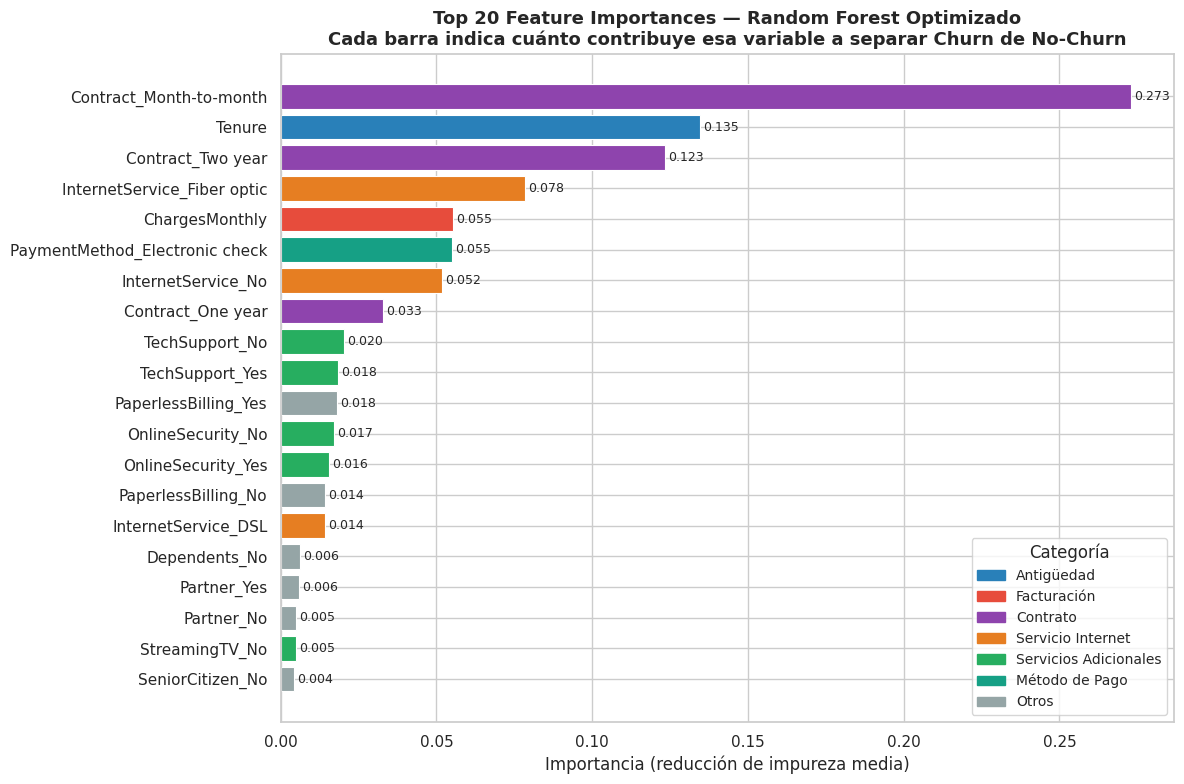


📊 Top 10 variables más importantes:
                       Feature  Importance
       Contract_Month-to-month    0.273107
                        Tenure    0.134653
             Contract_Two year    0.123226
   InternetService_Fiber optic    0.078409
                ChargesMonthly    0.055297
PaymentMethod_Electronic check    0.054887
            InternetService_No    0.051692
             Contract_One year    0.032964
                TechSupport_No    0.020424
               TechSupport_Yes    0.018445


In [58]:
# Extraer nombres de features tras OneHotEncoding
ohe_features = (rs_rf.best_estimator_
    .named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features).tolist())

all_features = numerical_features + ohe_features
importances  = rs_rf.best_estimator_.named_steps['classifier'].feature_importances_

feat_imp = (pd.DataFrame({'Feature': all_features, 'Importance': importances})
            .sort_values('Importance', ascending=False)
            .reset_index(drop=True))

top20 = feat_imp.head(20).copy()

# Asignar grupo temático para colorear
def grupo(feature):
    f = feature.lower()
    if 'tenure'    in f:                          return 'Antigüedad'
    if 'charges'   in f:                          return 'Facturación'
    if 'contract'  in f:                          return 'Contrato'
    if 'internet'  in f or 'fiber' in f:          return 'Servicio Internet'
    if any(s in f for s in ['security','backup','protection','support','streaming']): return 'Servicios Adicionales'
    if 'payment'   in f:                          return 'Método de Pago'
    return 'Otros'

top20['Grupo'] = top20['Feature'].apply(grupo)

palette = {
    'Antigüedad'          : '#2980b9',
    'Facturación'         : '#e74c3c',
    'Contrato'            : '#8e44ad',
    'Servicio Internet'   : '#e67e22',
    'Servicios Adicionales': '#27ae60',
    'Método de Pago'      : '#16a085',
    'Otros'               : '#95a5a6'
}
colors = top20['Grupo'].map(palette)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top20['Feature'][::-1], top20['Importance'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, top20['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Importancia (reducción de impureza media)', fontsize=12)
ax.set_title('Top 20 Feature Importances — Random Forest Optimizado\n'
             'Cada barra indica cuánto contribuye esa variable a separar Churn de No-Churn',
             fontsize=13, fontweight='bold')

legend_patches = [mpatches.Patch(color=c, label=g) for g, c in palette.items()
                  if g in top20['Grupo'].values]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10, title='Categoría')
plt.tight_layout()
plt.show()

print('\n📊 Top 10 variables más importantes:')
print(feat_imp[['Feature','Importance','Grupo'] if 'Grupo' in feat_imp.columns
               else ['Feature','Importance']].head(10).to_string(index=False))

### 10.2 Coeficientes — Regresión Logística (dirección del efecto)

Los coeficientes de la Regresión Logística representan el cambio en el **log-odds** de Churn por cada unidad de cambio en la variable (tras estandarización). A diferencia de la importancia del Random Forest, los coeficientes tienen **signo**:
- **Coeficiente positivo** → la variable aumenta la probabilidad de Churn.
- **Coeficiente negativo** → la variable reduce la probabilidad de Churn (factor protector).

La magnitud absoluta indica la fuerza del efecto. Se presentan por separado los factores de riesgo y los factores protectores para facilitar la lectura.

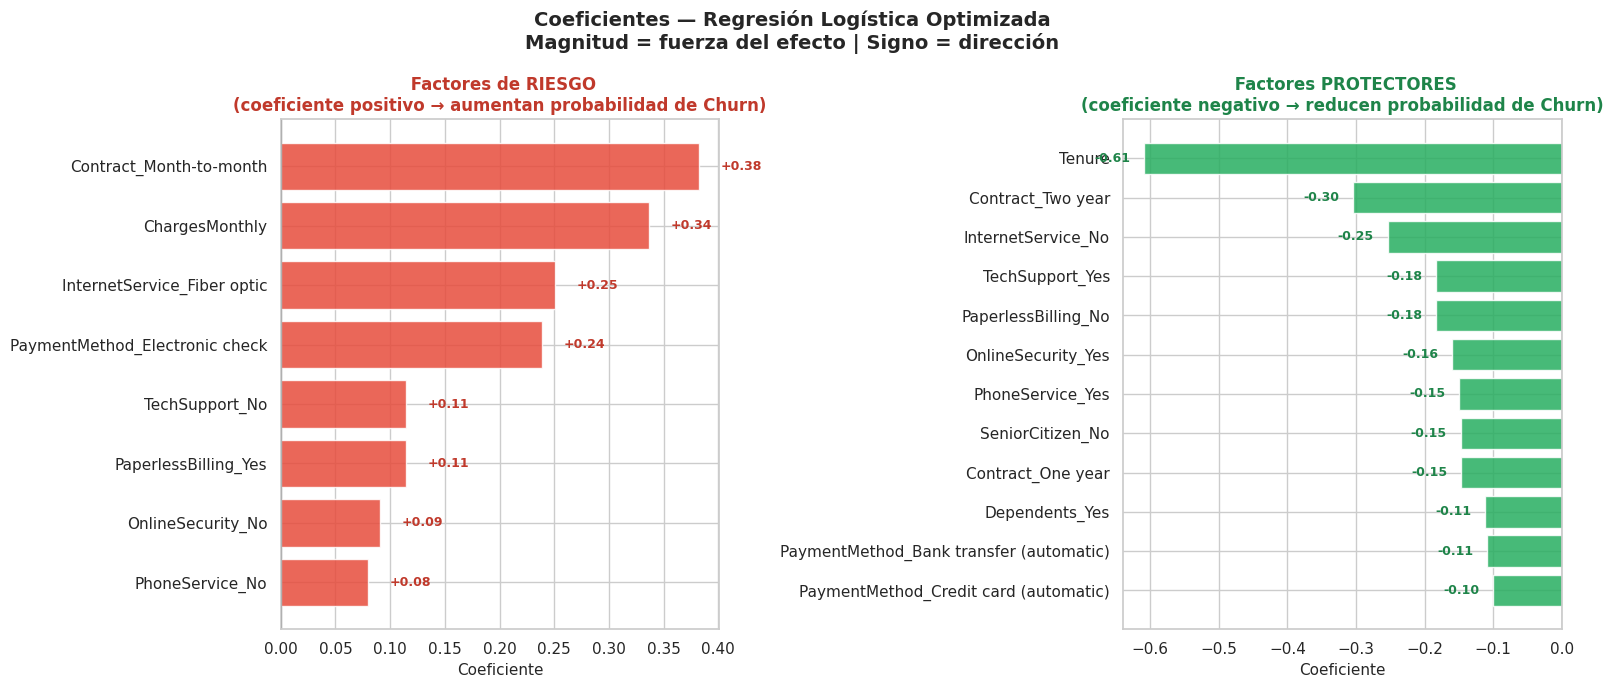

In [57]:
# Extraer coeficientes del modelo LR optimizado
ohe_lr = (rs_lr.best_estimator_
    .named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features).tolist())

coef = rs_lr.best_estimator_.named_steps['classifier'].coef_[0]

coef_df = (pd.DataFrame({'Feature': numerical_features + ohe_lr, 'Coeficiente': coef})
           .assign(Abs=lambda d: d['Coeficiente'].abs(),
                   Dirección=lambda d: d['Coeficiente'].apply(
                       lambda x: ' Aumenta Churn' if x > 0 else ' Reduce Churn'))
           .sort_values('Abs', ascending=False)
           .head(25).reset_index(drop=True))

# Separar en factores de riesgo y factores protectores
risk_df  = coef_df[coef_df['Coeficiente'] > 0].head(12)
prot_df  = coef_df[coef_df['Coeficiente'] < 0].head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel izquierdo: factores de RIESGO (coef positivo → más Churn)
risk_sorted = risk_df.sort_values('Coeficiente')
axes[0].barh(risk_sorted['Feature'], risk_sorted['Coeficiente'],
             color='#e74c3c', alpha=0.85, edgecolor='white')
for i, (_, row) in enumerate(risk_sorted.iterrows()):
    axes[0].text(row['Coeficiente'] + 0.02, i, f"+{row['Coeficiente']:.2f}",
                 va='center', fontsize=9, color='#c0392b', fontweight='bold')
axes[0].set_title(' Factores de RIESGO\n(coeficiente positivo → aumentan probabilidad de Churn)',
                  fontsize=12, fontweight='bold', color='#c0392b')
axes[0].set_xlabel('Coeficiente', fontsize=11)
axes[0].axvline(0, color='black', linewidth=0.8)

# Panel derecho: factores PROTECTORES (coef negativo → menos Churn)
prot_sorted = prot_df.sort_values('Coeficiente', ascending=False)
axes[1].barh(prot_sorted['Feature'], prot_sorted['Coeficiente'],
             color='#27ae60', alpha=0.85, edgecolor='white')
for i, (_, row) in enumerate(prot_sorted.iterrows()):
    axes[1].text(row['Coeficiente'] - 0.02, i, f"{row['Coeficiente']:.2f}",
                 va='center', ha='right', fontsize=9, color='#1e8449', fontweight='bold')
axes[1].set_title(' Factores PROTECTORES\n(coeficiente negativo → reducen probabilidad de Churn)',
                  fontsize=12, fontweight='bold', color='#1e8449')
axes[1].set_xlabel('Coeficiente', fontsize=11)
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Coeficientes — Regresión Logística Optimizada\n'
             'Magnitud = fuerza del efecto | Signo = dirección',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.3 Triangulación: Variables Relevantes en Ambos Modelos

Cuando una variable aparece en el Top 15 de importancia tanto del Random Forest como de la Regresión Logística, la evidencia de su relevancia es más robusta: dos algoritmos con supuestos distintos coinciden en que esa variable tiene poder predictivo. Esta **triangulación** reduce el riesgo de que la importancia sea un artefacto de un algoritmo específico.

In [28]:
# Variables que aparecen en el Top 15 de ambos modelos → mayor confianza
top15_rf = set(feat_imp.head(15)['Feature'].tolist())
top15_lr = set(coef_df.head(15)['Feature'].tolist())
coinciden = top15_rf & top15_lr

print('🎯 Variables que destacan en el Top 15 de AMBOS modelos:')
print('   (Alta confianza — señal consistente independiente del algoritmo)\n')
for v in sorted(coinciden):
    imp_val = feat_imp[feat_imp['Feature'] == v]['Importance'].values
    coe_val = coef_df[coef_df['Feature'] == v]['Coeficiente'].values
    imp_str = f"RF importance={imp_val[0]:.4f}" if len(imp_val) else ''
    coe_str = f"LR coef={coe_val[0]:+.3f}" if len(coe_val) else ''
    dir_str = '→ RIESGO' if (len(coe_val) and coe_val[0] > 0) else '→ PROTECTOR'
    print(f'   • {v:<45} {imp_str}  {coe_str}  {dir_str}')

🎯 Variables que destacan en el Top 15 de AMBOS modelos:
   (Alta confianza — señal consistente independiente del algoritmo)

   • ChargesMonthly                                RF importance=0.0553  LR coef=+0.337  → RIESGO
   • Contract_Month-to-month                       RF importance=0.2731  LR coef=+0.382  → RIESGO
   • Contract_One year                             RF importance=0.0330  LR coef=-0.147  → PROTECTOR
   • Contract_Two year                             RF importance=0.1232  LR coef=-0.304  → PROTECTOR
   • InternetService_Fiber optic                   RF importance=0.0784  LR coef=+0.250  → RIESGO
   • InternetService_No                            RF importance=0.0517  LR coef=-0.254  → PROTECTOR
   • OnlineSecurity_Yes                            RF importance=0.0157  LR coef=-0.160  → PROTECTOR
   • PaperlessBilling_No                           RF importance=0.0143  LR coef=-0.183  → PROTECTOR
   • PaperlessBilling_Yes                          RF importance=0.0181  LR 

### 10.4 Churn Rate Real por los Factores Más Relevantes

Para validar los hallazgos del modelo con los datos crudos, se calcula la tasa de Churn empírica por categoría de las variables identificadas como más relevantes. Si el modelo es coherente con los datos, las categorías con coeficientes positivos (factores de riesgo) deberían mostrar tasas de Churn superiores al promedio, y viceversa.

La línea punteada azul representa el promedio global de Churn (~26.5%) como referencia.

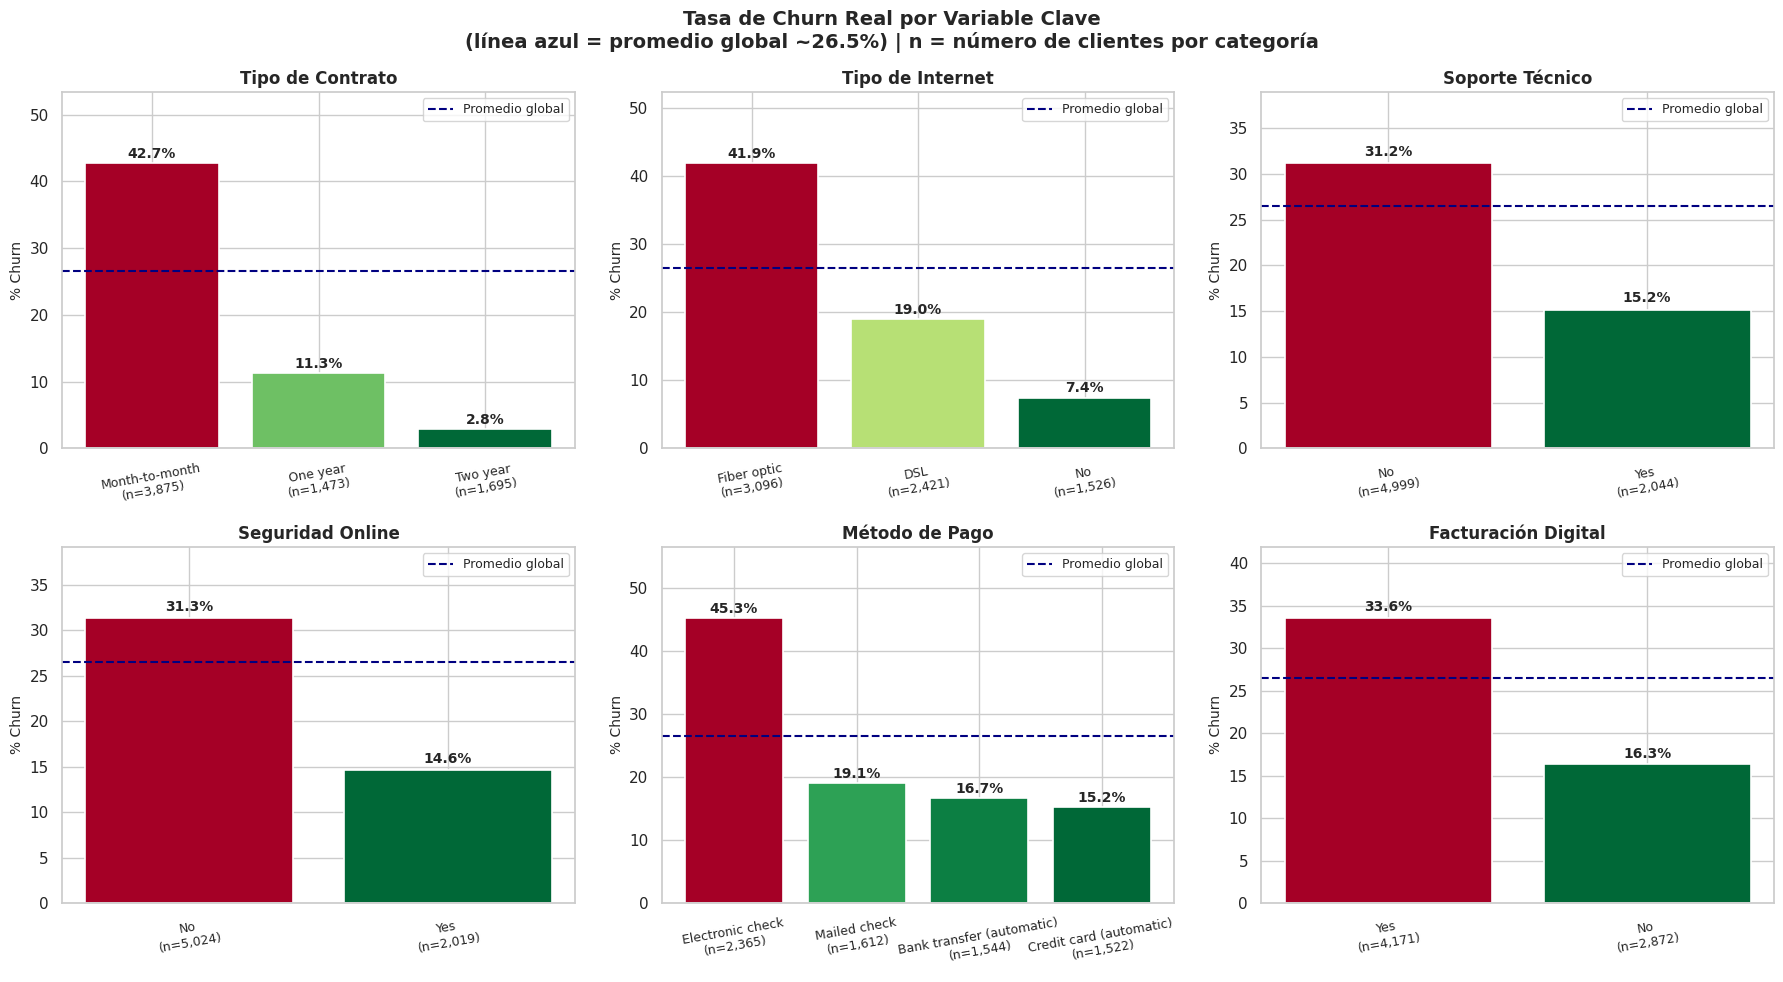

In [29]:
# Visualizar el churn rate empírico de las variables clave identificadas por los modelos
variables_clave = [
    ('Contract',        'Tipo de Contrato'),
    ('InternetService', 'Tipo de Internet'),
    ('TechSupport',     'Soporte Técnico'),
    ('OnlineSecurity',  'Seguridad Online'),
    ('PaymentMethod',   'Método de Pago'),
    ('PaperlessBilling','Facturación Digital'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, titulo) in zip(axes, variables_clave):
    ct = (df.groupby(col)['Churn']
            .apply(lambda x: (x == 'Yes').mean() * 100)
            .reset_index()
            .rename(columns={'Churn': 'ChurnRate'})
            .sort_values('ChurnRate', ascending=False))

    norm = plt.Normalize(ct['ChurnRate'].min(), ct['ChurnRate'].max())
    colors_bar = plt.cm.RdYlGn_r(norm(ct['ChurnRate'].values))

    bars = ax.bar(ct[col], ct['ChurnRate'], color=colors_bar, edgecolor='white', linewidth=1.2)
    ax.axhline(df['Churn'].eq('Yes').mean() * 100, color='navy',
               linestyle='--', linewidth=1.5, label=f'Promedio global')

    for bar, val in zip(bars, ct['ChurnRate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

    # Contar clientes por categoría
    counts = df[col].value_counts()
    xtick_labels = [f'{v}\n(n={counts.get(v,0):,})' for v in ct[col]]
    ax.set_xticks(range(len(ct)))
    ax.set_xticklabels(xtick_labels, fontsize=9, rotation=10)

    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('% Churn', fontsize=10)
    ax.set_ylim(0, max(ct['ChurnRate']) * 1.25)
    ax.legend(fontsize=9)

plt.suptitle('Tasa de Churn Real por Variable Clave\n'
             '(línea azul = promedio global ~26.5%) | n = número de clientes por categoría',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.5 Perfil del Cliente en Riesgo vs Cliente Retenido

Se comparan los valores promedio de las variables numéricas (`Tenure` y `ChargesMonthly`) entre los clientes que hicieron Churn y los que se retuvieron. Este perfil permite caracterizar al cliente en riesgo y al cliente leal, proporcionando una descripción concreta y accionable para los equipos comerciales.

📋 Perfil promedio — Churn vs No Churn (variables numéricas):
Churn           No Churn (retenido)  Churn (se fue)  Diferencia %
Tenure                        37.57           17.98         -52.1
ChargesMonthly                61.27           74.44          21.5


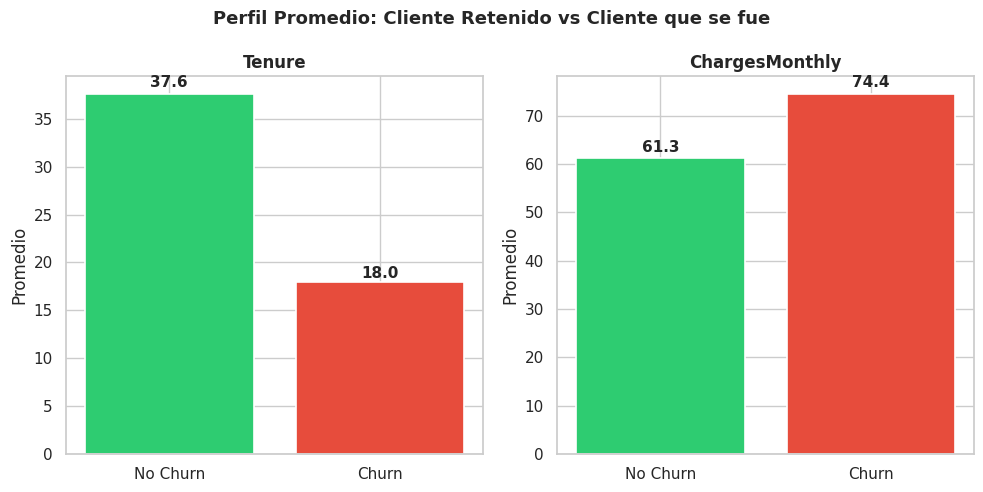

In [66]:
# Comparar promedios de variables numéricas entre Churn y No-Churn
perfil = (df.groupby('Churn')[['Tenure', 'ChargesMonthly']]
            .mean().T.rename(columns={'No': 'No Churn (retenido)', 'Yes': 'Churn (se fue)'}))

perfil['Diferencia %'] = ((perfil['Churn (se fue)'] - perfil['No Churn (retenido)'])
                           / perfil['No Churn (retenido)'] * 100).round(1)

print('📋 Perfil promedio — Churn vs No Churn (variables numéricas):')
print(perfil.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
vars_num = ['Tenure', 'ChargesMonthly']
colores_perfil = ['#2ecc71', '#e74c3c']

for ax, var in zip(axes, vars_num):
    vals = [df[df['Churn']=='No'][var].mean(), df[df['Churn']=='Yes'][var].mean()]
    bars = ax.bar(['No Churn', 'Churn'], vals, color=colores_perfil, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(var, fontsize=12, fontweight='bold')
    ax.set_ylabel('Promedio')

plt.suptitle('Perfil Promedio: Cliente Retenido vs Cliente que se fue',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Conclusiones de Negocio — Insights y Recomendaciones

Esta sección traduce los hallazgos técnicos del análisis en conclusiones accionables para el negocio. El objetivo es responder a la pregunta: **¿qué debe hacer TelecomX para reducir el Churn?**

Los insights se derivan directamente de los datos y están respaldados por el análisis exploratorio y la interpretabilidad de los modelos. Cada insight incluye:
- El hallazgo cuantificado (magnitud del efecto observado en los datos).
- La recomendación estratégica concreta derivada de ese hallazgo.

El resumen ejecutivo final consolida los insights en un plan de acción priorizado.

### 11.1 Insight 1 — El tipo de contrato es el predictor más poderoso

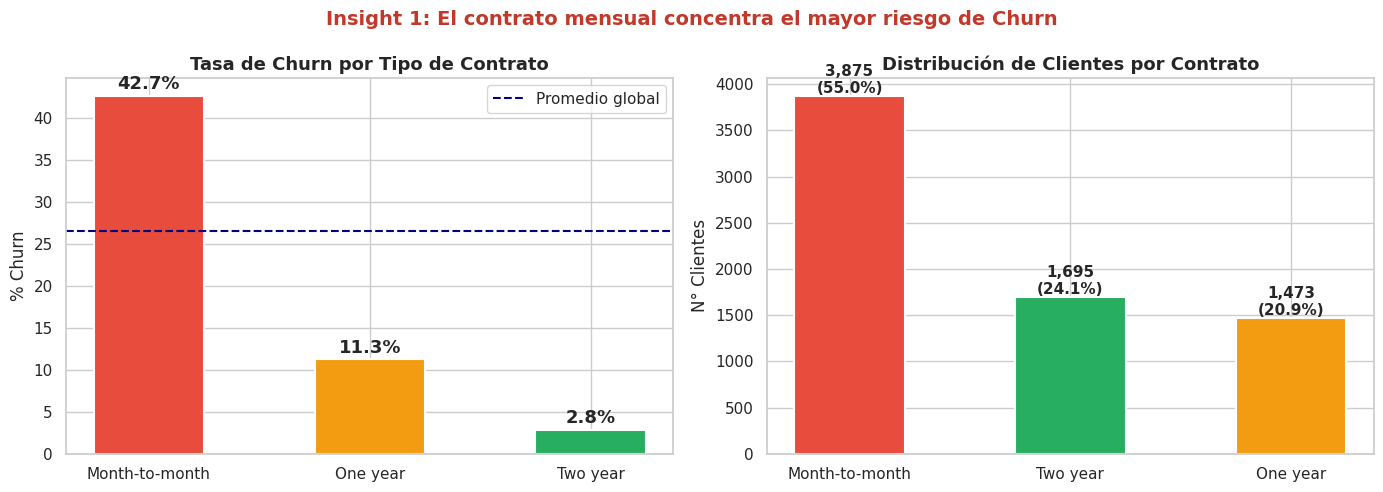


 HALLAZGO: Los clientes con contrato mensual tienen una tasa de Churn del 42.7%,
   más de 15x superior a los clientes con contrato bienal (2.8%).
   Representan el 55.0% de la base (3,875 clientes).

 ACCIÓN: Campaña de migración a contratos anuales con incentivo económico
   (descuento del 10-15% en los primeros 3 meses) dirigida a clientes
   mensuales con score de riesgo > 0.6.



In [65]:
contrato = (df.groupby('Contract')['Churn']
              .apply(lambda x: (x == 'Yes').mean() * 100)
              .reset_index()
              .rename(columns={'Churn': 'ChurnRate'})
              .sort_values('ChurnRate', ascending=False))

n_contrato = df['Contract'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate
bars = axes[0].bar(contrato['Contract'], contrato['ChurnRate'],
                   color=['#e74c3c', '#f39c12', '#27ae60'], edgecolor='white', linewidth=1.5, width=0.5)
axes[0].axhline(df['Churn'].eq('Yes').mean()*100, linestyle='--',
                color='navy', linewidth=1.5, label='Promedio global')
for bar, val in zip(bars, contrato['ChurnRate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Tasa de Churn por Tipo de Contrato', fontsize=13, fontweight='bold')
axes[0].set_ylabel('% Churn')
axes[0].legend()

# Distribución de clientes
axes[1].bar(n_contrato.index, n_contrato.values,
            color=['#e74c3c', '#27ae60', '#f39c12'], edgecolor='white', linewidth=1.5, width=0.5)
for i, (idx, val) in enumerate(n_contrato.items()):
    axes[1].text(i, val + 30, f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Distribución de Clientes por Contrato', fontsize=13, fontweight='bold')
axes[1].set_ylabel('N° Clientes')

plt.suptitle('Insight 1: El contrato mensual concentra el mayor riesgo de Churn',
             fontsize=14, fontweight='bold', color='#c0392b')
plt.tight_layout()
plt.show()

mensual = contrato[contrato['Contract']=='Month-to-month']['ChurnRate'].values[0]
anual   = contrato[contrato['Contract']=='Two year']['ChurnRate'].values[0]
print(f"""
 HALLAZGO: Los clientes con contrato mensual tienen una tasa de Churn del {mensual:.1f}%,
   más de {mensual/anual:.0f}x superior a los clientes con contrato bienal ({anual:.1f}%).
   Representan el {n_contrato['Month-to-month']/len(df)*100:.1f}% de la base ({n_contrato['Month-to-month']:,} clientes).

 ACCIÓN: Campaña de migración a contratos anuales con incentivo económico
   (descuento del 10-15% en los primeros 3 meses) dirigida a clientes
   mensuales con score de riesgo > 0.6.
""")

### 11.2 Insight 2 — Los clientes nuevos son los más vulnerables

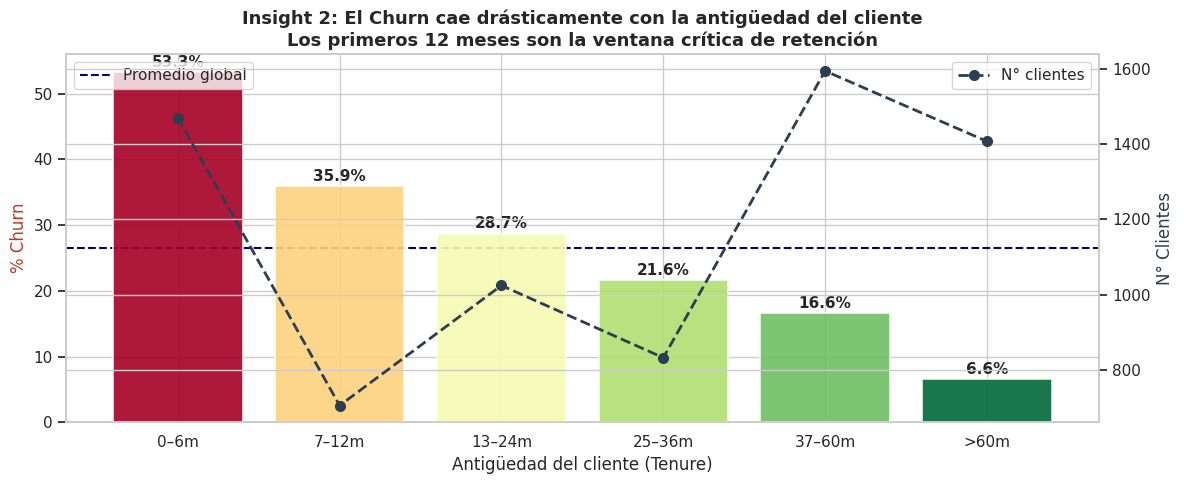


💡 HALLAZGO: Los clientes en sus primeros 6 meses tienen un Churn de 53.3%,
   vs solo 6.6% en clientes con más de 5 años.
   La relación es casi lineal inversa: a mayor tiempo, menor riesgo.

🎯 ACCIÓN: Programa de onboarding estructurado en los primeros 90 días:
   - Llamada de bienvenida al día 7
   - Revisión de uso y satisfacción al mes 3
   - Oferta de servicio adicional gratuito al mes 6 para reducir el riesgo de salida



In [64]:
df['TenureBand'] = pd.cut(df['Tenure'],
                           bins  = [0, 6, 12, 24, 36, 60, 200],
                           labels= ['0–6m', '7–12m', '13–24m', '25–36m', '37–60m', '>60m'])

tenure_churn = (df.groupby('TenureBand', observed=True)['Churn']
                  .apply(lambda x: (x=='Yes').mean() * 100)
                  .reset_index()
                  .rename(columns={'Churn': 'ChurnRate'}))

tenure_count = df.groupby('TenureBand', observed=True).size().reset_index(name='Count')
tenure_data  = tenure_churn.merge(tenure_count)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

norm = plt.Normalize(tenure_data['ChurnRate'].min(), tenure_data['ChurnRate'].max())
bar_colors = plt.cm.RdYlGn_r(norm(tenure_data['ChurnRate'].values))

bars = ax1.bar(tenure_data['TenureBand'].astype(str), tenure_data['ChurnRate'],
               color=bar_colors, edgecolor='white', linewidth=1.2, alpha=0.9, zorder=3)
ax2.plot(tenure_data['TenureBand'].astype(str), tenure_data['Count'],
         'o--', color='#2c3e50', linewidth=2, markersize=7, label='N° clientes', zorder=4)

for bar, val in zip(bars, tenure_data['ChurnRate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax1.set_xlabel('Antigüedad del cliente (Tenure)', fontsize=12)
ax1.set_ylabel('% Churn', fontsize=12, color='#c0392b')
ax2.set_ylabel('N° Clientes', fontsize=12, color='#2c3e50')
ax1.axhline(df['Churn'].eq('Yes').mean()*100, linestyle='--',
            color='navy', linewidth=1.5, label='Promedio global', zorder=2)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Insight 2: El Churn cae drásticamente con la antigüedad del cliente\n'
          'Los primeros 12 meses son la ventana crítica de retención',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

churn_0_6  = tenure_data[tenure_data['TenureBand']=='0–6m']['ChurnRate'].values[0]
churn_60p  = tenure_data[tenure_data['TenureBand']=='>60m']['ChurnRate'].values[0]
print(f"""
💡 HALLAZGO: Los clientes en sus primeros 6 meses tienen un Churn de {churn_0_6:.1f}%,
   vs solo {churn_60p:.1f}% en clientes con más de 5 años.
   La relación es casi lineal inversa: a mayor tiempo, menor riesgo.

🎯 ACCIÓN: Programa de onboarding estructurado en los primeros 90 días:
   - Llamada de bienvenida al día 7
   - Revisión de uso y satisfacción al mes 3
   - Oferta de servicio adicional gratuito al mes 6 para reducir el riesgo de salida
""")

### 11.3 Insight 3 — Los servicios adicionales actúan como ancla de retención

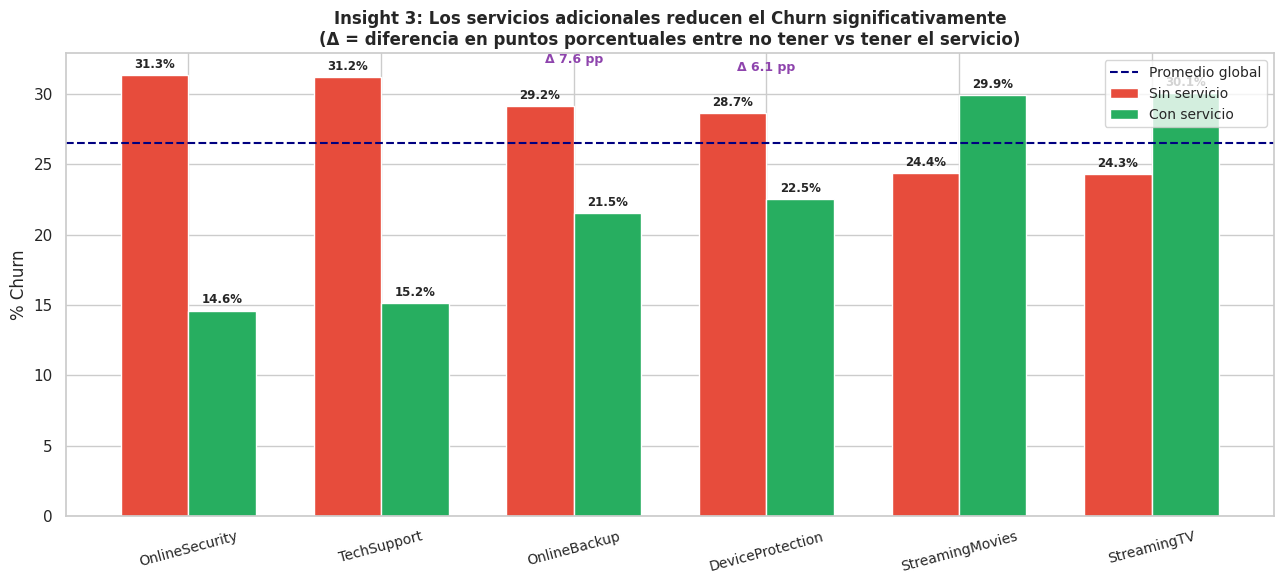


💡 HALLAZGO: El servicio con mayor efecto protector es 'OnlineSecurity'.
   Los clientes SIN ese servicio abandonan un 16.7 pp más que los que SÍ lo tienen.
   OnlineSecurity y TechSupport son los servicios más críticos para la retención.

🎯 ACCIÓN: Ofrecer 3 meses gratuitos de OnlineSecurity + TechSupport
   a clientes mensual sin servicios adicionales y con Tenure < 12 meses.
   Esto ataca simultáneamente los Insights 1, 2 y 3.



In [62]:
servicios = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection',
             'StreamingTV', 'StreamingMovies']

# Tasa de Churn para quienes tienen vs no tienen cada servicio
rows = []
for s in servicios:
    tiene    = df[df[s]=='Yes']['Churn'].eq('Yes').mean() * 100
    no_tiene = df[df[s]=='No' ]['Churn'].eq('Yes').mean() * 100
    rows.append({'Servicio': s, 'Con servicio': tiene, 'Sin servicio': no_tiene,
                 'Diferencia': no_tiene - tiene})

srv_df = pd.DataFrame(rows).sort_values('Diferencia', ascending=False)

x    = np.arange(len(srv_df))
ancho = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - ancho/2, srv_df['Sin servicio'], ancho,
            label='Sin servicio', color='#e74c3c', edgecolor='white', linewidth=1)
b2 = ax.bar(x + ancho/2, srv_df['Con servicio'], ancho,
            label='Con servicio', color='#27ae60', edgecolor='white', linewidth=1)

for bar, val in [(b, v) for b, v in zip(list(b1)+list(b2),
                  list(srv_df['Sin servicio'])+list(srv_df['Con servicio']))]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=8.5, fontweight='bold')

# Anotar diferencia
for i, (_, row) in enumerate(srv_df.iterrows()):
    ax.annotate(f'Δ {row["Diferencia"]:.1f} pp',
                xy=(i, max(row['Sin servicio'], row['Con servicio']) + 3),
                ha='center', fontsize=9, color='#8e44ad', fontweight='bold')

ax.axhline(df['Churn'].eq('Yes').mean()*100, linestyle='--',
           color='navy', linewidth=1.5, label='Promedio global')
ax.set_xticks(x)
ax.set_xticklabels(srv_df['Servicio'], rotation=15, fontsize=10)
ax.set_ylabel('% Churn', fontsize=12)
ax.set_title('Insight 3: Los servicios adicionales reducen el Churn significativamente\n'
             '(Δ = diferencia en puntos porcentuales entre no tener vs tener el servicio)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

top_srv = srv_df.iloc[0]
print(f"""
💡 HALLAZGO: El servicio con mayor efecto protector es '{top_srv['Servicio']}'.
   Los clientes SIN ese servicio abandonan un {top_srv['Diferencia']:.1f} pp más que los que SÍ lo tienen.
   OnlineSecurity y TechSupport son los servicios más críticos para la retención.

🎯 ACCIÓN: Ofrecer 3 meses gratuitos de OnlineSecurity + TechSupport
   a clientes mensual sin servicios adicionales y con Tenure < 12 meses.
   Esto ataca simultáneamente los Insights 1, 2 y 3.
""")

### 11.4 Insight 4 — Cargos mensuales altos con poco vínculo = perfil de mayor riesgo

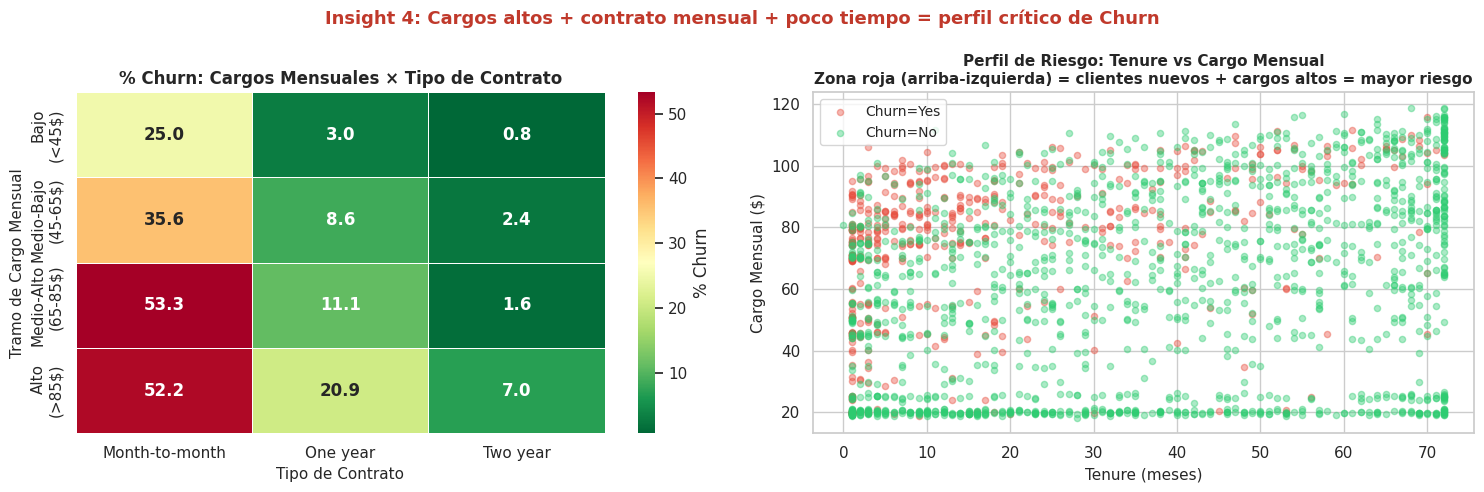


💡 HALLAZGO: El peor perfil combina cargo mensual alto + contrato mes a mes.
   Esos clientes presentan hasta un 53.3% de Churn.
   En el scatter se observa la zona crítica: Tenure < 20 meses + Charges > $70.

🎯 ACCIÓN: Segmento prioritario para retención proactiva:
   Tenure < 12 meses + Contrato mensual + ChargesMonthly > $65
   → Score de riesgo elevado → intervención comercial inmediata.



In [61]:
# Cruzar ChargesMonthly con Contract para ver el perfil de riesgo combinado
df['ChargeBand'] = pd.qcut(df['ChargesMonthly'], q=4,
                            labels=['Bajo\n(<45$)', 'Medio-Bajo\n(45-65$)',
                                    'Medio-Alto\n(65-85$)', 'Alto\n(>85$)'])

heatmap_data = (df.groupby(['ChargeBand', 'Contract'], observed=True)['Churn']
                  .apply(lambda x: (x=='Yes').mean() * 100)
                  .reset_index()
                  .rename(columns={'Churn': 'ChurnRate'})
                  .pivot(index='ChargeBand', columns='Contract', values='ChurnRate'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': '% Churn'}, ax=axes[0],
            annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_title('% Churn: Cargos Mensuales × Tipo de Contrato',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tipo de Contrato', fontsize=11)
axes[0].set_ylabel('Tramo de Cargo Mensual', fontsize=11)

# Scatter: Tenure vs ChargesMonthly coloreado por Churn
sample = df.sample(2000, random_state=42)
churn_map = {'Yes': '#e74c3c', 'No': '#2ecc71'}
for label, color in churn_map.items():
    mask = sample['Churn'] == label
    axes[1].scatter(sample[mask]['Tenure'], sample[mask]['ChargesMonthly'],
                    c=color, alpha=0.4, s=20, label=f'Churn={label}')
axes[1].set_xlabel('Tenure (meses)', fontsize=11)
axes[1].set_ylabel('Cargo Mensual ($)', fontsize=11)
axes[1].set_title('Perfil de Riesgo: Tenure vs Cargo Mensual\n'
                  'Zona roja (arriba-izquierda) = clientes nuevos + cargos altos = mayor riesgo',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Insight 4: Cargos altos + contrato mensual + poco tiempo = perfil crítico de Churn',
             fontsize=13, fontweight='bold', color='#c0392b')
plt.tight_layout()
plt.show()

peor = heatmap_data['Month-to-month'].max()
print(f"""
💡 HALLAZGO: El peor perfil combina cargo mensual alto + contrato mes a mes.
   Esos clientes presentan hasta un {peor:.1f}% de Churn.
   En el scatter se observa la zona crítica: Tenure < 20 meses + Charges > $70.

🎯 ACCIÓN: Segmento prioritario para retención proactiva:
   Tenure < 12 meses + Contrato mensual + ChargesMonthly > $65
   → Score de riesgo elevado → intervención comercial inmediata.
""")

### 11.5 Resumen Ejecutivo — Business Conclusions

In [68]:
mejor_recall = tabla['Recall'].idxmax()
mejor_roc    = tabla['ROC-AUC'].idxmax()

# Calcular métricas clave para el resumen
n_churn      = df['Churn'].eq('Yes').sum()
pct_churn    = df['Churn'].eq('Yes').mean() * 100
pct_mensual  = df[df['Contract']=='Month-to-month']['Churn'].eq('Yes').mean() * 100
pct_0_6      = df[df['TenureBand']=='0–6m']['Churn'].eq('Yes').mean() * 100
pct_sin_sec  = df[df['OnlineSecurity']=='No']['Churn'].eq('Yes').mean() * 100
pct_con_sec  = df[df['OnlineSecurity']=='Yes']['Churn'].eq('Yes').mean() * 100

print(f"""
══════════════════════════════════════════════════════════════════════════
               BUSINESS CONCLUSIONS — TELECOMX CHURN
══════════════════════════════════════════════════════════════════════════

CONTEXTO
  Dataset  : 7,043 clientes | {n_churn:,} con Churn ({pct_churn:.1f}%)
  Modelo   : {mejor_recall} — Recall {tabla.loc[mejor_recall,'Recall']:.3f} | AUC {tabla.loc[mejor_roc,'ROC-AUC']:.3f}
  Problema : Detectar clientes antes de que se vayan para actuar a tiempo

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 1 — El contrato es el factor más determinante
  • Clientes con contrato mes a mes:  {pct_mensual:.1f}% de Churn
  • Son el 55% de la base → mayor grupo de riesgo
  → Migrar a contrato anual reduce el riesgo de forma inmediata

INSIGHT 2 — Los primeros 12 meses son críticos
  • Churn en clientes 0–6 meses:   {pct_0_6:.1f}%
  • La fidelización cae drásticamente después del año 1
  → El onboarding determina si el cliente se queda o se va

INSIGHT 3 — Los servicios adicionales retienen
  • Sin OnlineSecurity: {pct_sin_sec:.1f}% Churn | Con OnlineSecurity: {pct_con_sec:.1f}% Churn
  • Diferencia de {pct_sin_sec - pct_con_sec:.1f} pp → el servicio actúa como ancla
  → Regalar servicios adicionales reduce el Churn y aumenta el ARPU

INSIGHT 4 — Cargos altos + vínculos débiles = perfil crítico
  • Clientes nuevos (<12 meses) con cargos >$70 presentan Churn >50%
  • El precio no es el problema: es la falta de valor percibido
  → Justificar el precio con servicios de valor en los primeros meses

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RECOMENDACIONES ACCIONABLES (por prioridad)

  🥇 ALTA PRIORIDAD
     1. Score mensual de riesgo para los {(df['Contract']=='Month-to-month').sum():,} clientes mensuales
        → Contacto preventivo cuando score > 0.65
     2. Campaña de migración a contrato anual con descuento del 10%
        → Target: contrato mensual + Tenure < 12 meses

  🥈 MEDIA PRIORIDAD
     3. Programa de onboarding (días 7, 30, 90) para clientes nuevos
     4. Bundle gratuito OnlineSecurity + TechSupport (3 meses) para
        clientes sin servicios adicionales y contrato mensual

  🥉 LARGO PLAZO
     5. Revisar pricing y calidad del servicio de Fibra Óptica
        (Churn elevado sugiere insatisfacción con el servicio)
     6. Desarrollar modelo de propensión a upgrade para clientes
        con alto Tenure y bajo número de servicios adicionales
""")


══════════════════════════════════════════════════════════════════════════
               BUSINESS CONCLUSIONS — TELECOMX CHURN                  
══════════════════════════════════════════════════════════════════════════

CONTEXTO
  Dataset  : 7,043 clientes | 1,869 con Churn (26.5%)
  Modelo   : RF  Optimizado — Recall 0.810 | AUC 0.842
  Problema : Detectar clientes antes de que se vayan para actuar a tiempo

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INSIGHT 1 — El contrato es el factor más determinante
  • Clientes con contrato mes a mes:  42.7% de Churn
  • Son el 55% de la base → mayor grupo de riesgo
  → Migrar a contrato anual reduce el riesgo de forma inmediata

INSIGHT 2 — Los primeros 12 meses son críticos
  • Churn en clientes 0–6 meses:   53.3%
  • La fidelización cae drásticamente después del año 1
  → El onboarding determina si el cliente se queda o se va

INSIGHT 3 — Los servicios adicionales retienen
  • Sin OnlineSecurity: 31.3% Churn | Con 

---
## Recomendación Estratégica Final

El modelo permite identificar perfiles con mayor probabilidad de evasión, especialmente clientes con contratos mensuales, menor antigüedad y menor cantidad de servicios contratados.

Se recomienda que Telecom X implemente **estrategias de retención enfocadas en**:

- **Clientes nuevos** durante sus primeros meses de servicio, cuando el riesgo de Churn es más alto.
- **Clientes con contrato mensual**, que concentran la mayor tasa de cancelación de toda la base.
- **Clientes con alta facturación pero bajo nivel de fidelización**, combinación que define el perfil de mayor riesgo.

Además, se podría utilizar el modelo como **sistema de alerta temprana**, ejecutándolo periódicamente para anticipar cancelaciones y activar campañas preventivas antes de que el cliente decida irse.

Este enfoque transforma el análisis de datos en una herramienta de negocio concreta: pasar de reaccionar ante el Churn a **prevenirlo**.

---
*Notebook: TelecomX — Detección de Churn | Febrero 2026*  
*Modelos: Regresión Logística + Random Forest | RandomizedSearchCV (scoring=recall) | Stratify 80/20*  
*Variables eliminadas por multicolinealidad: `ChargesDaily` (r=1.00 con Monthly) y `ChargesTotal` (r=0.83 con Tenure)*